# ENG2440 Assignment 1 - RSNA pneumonia classification

The target is **lung opacity that could be pneumonia**, not a confirmed pneumonia diagnosis. The negative class has both Normal and No Lung Opacity / Not Normal exams.

## 1. Setup

In [12]:
# gpu if available (cuda on my pc, mps on mac)

import torch

if torch.cuda.is_available():
    device = torch.device("cuda")   # Windows RTX
elif torch.backends.mps.is_available():
    device = torch.device("mps")    # Mac M4 Max
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [13]:
# imports

from pathlib import Path

import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import numpy as np 
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler

c:\Users\11\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Labels: from annotation rows to one label per exam

In [14]:
# paths + load the csvs
# 25684 dicoms and 25684 unique exams, so one image per exam

DATA_ROOT = Path("data/images")
LABEL_FILE = Path("assignment1_labels.csv")
MAPPING_FILE = Path("rsna_to_nih_mapping.csv")

dicom_files = list(DATA_ROOT.rglob("*.dcm"))

assert len(dicom_files) > 0, "No DICOM files were found."
assert LABEL_FILE.exists(), "The label file was not found."
assert MAPPING_FILE.exists(), "The mapping file was not found."

labels = pd.read_csv(LABEL_FILE)
mapping = pd.read_csv(MAPPING_FILE)

print("DICOM files:", len(dicom_files))
print("Annotation rows:", len(labels))
print("Unique examinations:", labels["patientId"].nunique())
print("Unique source patients:", mapping["nih_patient_id"].nunique())

display(labels.head())
display(mapping.head())

DICOM files: 25684
Annotation rows: 28989
Unique examinations: 25684
Unique source patients: 11171


,patientId,x,y,width,height,Target,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID
0,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.5872.151787431...,1.2.276.0.7230010.3.1.3.8323329.5872.151787431...,1.2.276.0.7230010.3.1.4.8323329.5872.151787431...
1,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.15466.15178743...,1.2.276.0.7230010.3.1.3.8323329.15466.15178743...,1.2.276.0.7230010.3.1.4.8323329.15466.15178743...
2,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,564.0,356.0,274.0,496.0,1,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...
3,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...,195.0,320.0,281.0,515.0,1,1.2.276.0.7230010.3.1.2.8323329.10973.15178743...,1.2.276.0.7230010.3.1.3.8323329.10973.15178743...,1.2.276.0.7230010.3.1.4.8323329.10973.15178743...
4,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...,NaN,NaN,NaN,NaN,0,1.2.276.0.7230010.3.1.2.8323329.22658.15178744...,1.2.276.0.7230010.3.1.3.8323329.22658.15178744...,1.2.276.0.7230010.3.1.4.8323329.22658.15178744...


,patientId,nih_patient_id,nih_image_id
0,1.2.276.0.7230010.3.1.4.8323329.1476.151787429...,30497,00030497_003.png
1,1.2.276.0.7230010.3.1.4.8323329.1472.151787429...,102,00000102_000.png
2,1.2.276.0.7230010.3.1.4.8323329.1477.151787429...,954,00000954_002.png
3,1.2.276.0.7230010.3.1.4.8323329.1479.151787429...,9391,00009391_000.png
4,1.2.276.0.7230010.3.1.4.8323329.1478.151787429...,5094,00005094_003.png


In [15]:
# look at the label file, the NaN boxes are the negative rows

print(labels.info())

display(labels.isna().sum())

display(labels["Target"].value_counts())

annotations_per_exam = labels.groupby("patientId").size()

display(annotations_per_exam.value_counts().sort_index())

<class 'pandas.DataFrame'>
RangeIndex: 28989 entries, 0 to 28988
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   patientId          28989 non-null  str    
 1   x                  8964 non-null   float64
 2   y                  8964 non-null   float64
 3   width              8964 non-null   float64
 4   height             8964 non-null   float64
 5   Target             28989 non-null  int64  
 6   StudyInstanceUID   28989 non-null  str    
 7   SeriesInstanceUID  28989 non-null  str    
 8   SOPInstanceUID     28989 non-null  str    
dtypes: float64(4), int64(1), str(4)
memory usage: 2.0 MB
None


patientId                0
x                    20025
y                    20025
width                20025
height               20025
Target                   0
StudyInstanceUID         0
SeriesInstanceUID        0
SOPInstanceUID           0
dtype: int64

Target
0    20025
1     8964
Name: count, dtype: int64

1    22506
2     3062
3      105
4       11
Name: count, dtype: int64

In [16]:
# collapse to one label per exam (max of Target)
# around 22% positive after this

exam_labels = (
    labels.groupby("patientId", as_index=False)["Target"]
    .max()
)

print("Examinations:", len(exam_labels))
display(exam_labels["Target"].value_counts())
display(exam_labels["Target"].value_counts(normalize=True))

Examinations: 25684


Target
0    20025
1     5659
Name: count, dtype: int64

Target
0    0.779668
1    0.220332
Name: proportion, dtype: float64

In [17]:
# check the boxes match the labels + exams with more than one row
# repeated rows are just multiple boxes on the same image

bbox_columns = ["x", "y", "width", "height"]

positive_rows = labels[labels["Target"] == 1]
negative_rows = labels[labels["Target"] == 0]

annotation_checks = pd.Series({
    "Positive rows with complete bounding boxes":
        positive_rows[bbox_columns].notna().all(axis=1).sum(),

    "Negative rows with no bounding box":
        negative_rows[bbox_columns].isna().all(axis=1).sum(),

    "Examinations with repeated annotation rows":
        (annotations_per_exam > 1).sum(),
})

display(annotation_checks)

duplicate_annotations = labels[
    labels["patientId"].duplicated(keep=False)
].sort_values("patientId")

display(duplicate_annotations.head(10))

Positive rows with complete bounding boxes     8964
Negative rows with no bounding box            20025
Examinations with repeated annotation rows     3178
dtype: int64

,patientId,x,y,width,height,Target,StudyInstanceUID,SeriesInstanceUID,SOPInstanceUID
481,1.2.276.0.7230010.3.1.4.8323329.10009.15178743...,611.0,515.0,393.0,327.0,1,1.2.276.0.7230010.3.1.2.8323329.10009.15178743...,1.2.276.0.7230010.3.1.3.8323329.10009.15178743...,1.2.276.0.7230010.3.1.4.8323329.10009.15178743...
532,1.2.276.0.7230010.3.1.4.8323329.10009.15178743...,13.0,526.0,422.0,296.0,1,1.2.276.0.7230010.3.1.2.8323329.10009.15178743...,1.2.276.0.7230010.3.1.3.8323329.10009.15178743...,1.2.276.0.7230010.3.1.4.8323329.10009.15178743...
1890,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...,287.0,254.0,82.0,70.0,1,1.2.276.0.7230010.3.1.2.8323329.10028.15178743...,1.2.276.0.7230010.3.1.3.8323329.10028.15178743...,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...
1940,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...,635.0,622.0,103.0,155.0,1,1.2.276.0.7230010.3.1.2.8323329.10028.15178743...,1.2.276.0.7230010.3.1.3.8323329.10028.15178743...,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...
1941,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...,283.0,394.0,133.0,291.0,1,1.2.276.0.7230010.3.1.2.8323329.10028.15178743...,1.2.276.0.7230010.3.1.3.8323329.10028.15178743...,1.2.276.0.7230010.3.1.4.8323329.10028.15178743...
12675,1.2.276.0.7230010.3.1.4.8323329.10029.15178743...,573.0,256.0,189.0,428.0,1,1.2.276.0.7230010.3.1.2.8323329.10029.15178743...,1.2.276.0.7230010.3.1.3.8323329.10029.15178743...,1.2.276.0.7230010.3.1.4.8323329.10029.15178743...
12676,1.2.276.0.7230010.3.1.4.8323329.10029.15178743...,303.0,197.0,207.0,408.0,1,1.2.276.0.7230010.3.1.2.8323329.10029.15178743...,1.2.276.0.7230010.3.1.3.8323329.10029.15178743...,1.2.276.0.7230010.3.1.4.8323329.10029.15178743...
1103,1.2.276.0.7230010.3.1.4.8323329.10034.15178743...,615.0,278.0,332.0,320.0,1,1.2.276.0.7230010.3.1.2.8323329.10034.15178743...,1.2.276.0.7230010.3.1.3.8323329.10034.15178743...,1.2.276.0.7230010.3.1.4.8323329.10034.15178743...
1102,1.2.276.0.7230010.3.1.4.8323329.10034.15178743...,313.0,430.0,211.0,256.0,1,1.2.276.0.7230010.3.1.2.8323329.10034.15178743...,1.2.276.0.7230010.3.1.3.8323329.10034.15178743...,1.2.276.0.7230010.3.1.4.8323329.10034.15178743...
19685,1.2.276.0.7230010.3.1.4.8323329.10040.15178743...,612.0,579.0,274.0,222.0,1,1.2.276.0.7230010.3.1.2.8323329.10040.15178743...,1.2.276.0.7230010.3.1.3.8323329.10040.15178743...,1.2.276.0.7230010.3.1.4.8323329.10040.15178743...


## 3. Linking exams to the original NIH patients

In [18]:
# merge with the nih mapping, every exam matched
# some patients have a lot of exams (max 63) so the split has to be by patient

dataset = exam_labels.merge(
    mapping,
    on="patientId",
    how="left",
    validate="one_to_one",
    indicator=True,
)

display(dataset["_merge"].value_counts())

assert dataset["_merge"].eq("both").all(), "Some examinations have no NIH mapping."

dataset = dataset.drop(columns="_merge")

exams_per_source_patient = (
    dataset.groupby("nih_patient_id")["patientId"]
    .nunique()
)

print("Unique source patients:", dataset["nih_patient_id"].nunique())
print("Patients with multiple examinations:", (exams_per_source_patient > 1).sum())

display(exams_per_source_patient.describe())

_merge
both          25684
left_only         0
right_only        0
Name: count, dtype: int64

Unique source patients: 11171
Patients with multiple examinations: 4198


count    11171.000000
mean         2.299167
std          3.307870
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         63.000000
Name: patientId, dtype: float64

## 4. DICOM metadata

In [19]:
# read the dicom headers only (much faster)
# all 1024x1024, MONOCHROME2, views are PA and AP

metadata_rows = []

for dcm_path in dicom_files:
    dicom = pydicom.dcmread(
        dcm_path,
        stop_before_pixels=True,
        specific_tags=[
            "Rows",
            "Columns",
            "PhotometricInterpretation",
            "ViewPosition",
            "PatientSex",
            "Modality",
        ],
    )

    metadata_rows.append({
        "patientId": dcm_path.stem,
        "dicom_path": dcm_path,
        "Rows": getattr(dicom, "Rows", None),
        "Columns": getattr(dicom, "Columns", None),
        "PhotometricInterpretation": getattr(
            dicom, "PhotometricInterpretation", None
        ),
        "ViewPosition": getattr(dicom, "ViewPosition", None),
        "PatientSex": getattr(dicom, "PatientSex", None),
        "Modality": getattr(dicom, "Modality", None),
    })

dicom_metadata = pd.DataFrame(metadata_rows)

dataset = dataset.merge(
    dicom_metadata,
    on="patientId",
    how="left",
    validate="one_to_one",
)

for column in [
    "Rows",
    "Columns",
    "PhotometricInterpretation",
    "ViewPosition",
    "PatientSex",
    "Modality",
]:
    print(f"\n{column}")
    display(dataset[column].value_counts(dropna=False))


Rows


Rows
1024    25684
Name: count, dtype: int64


Columns


Columns
1024    25684
Name: count, dtype: int64


PhotometricInterpretation


...

ViewPosition
PA    13979
AP    11705
Name: count, dtype: int64


PatientSex


PatientSex
M    14593
F    11091
Name: count, dtype: int64


Modality


Modality
CR    25684
Name: count, dtype: int64

## 5. Looking at the images

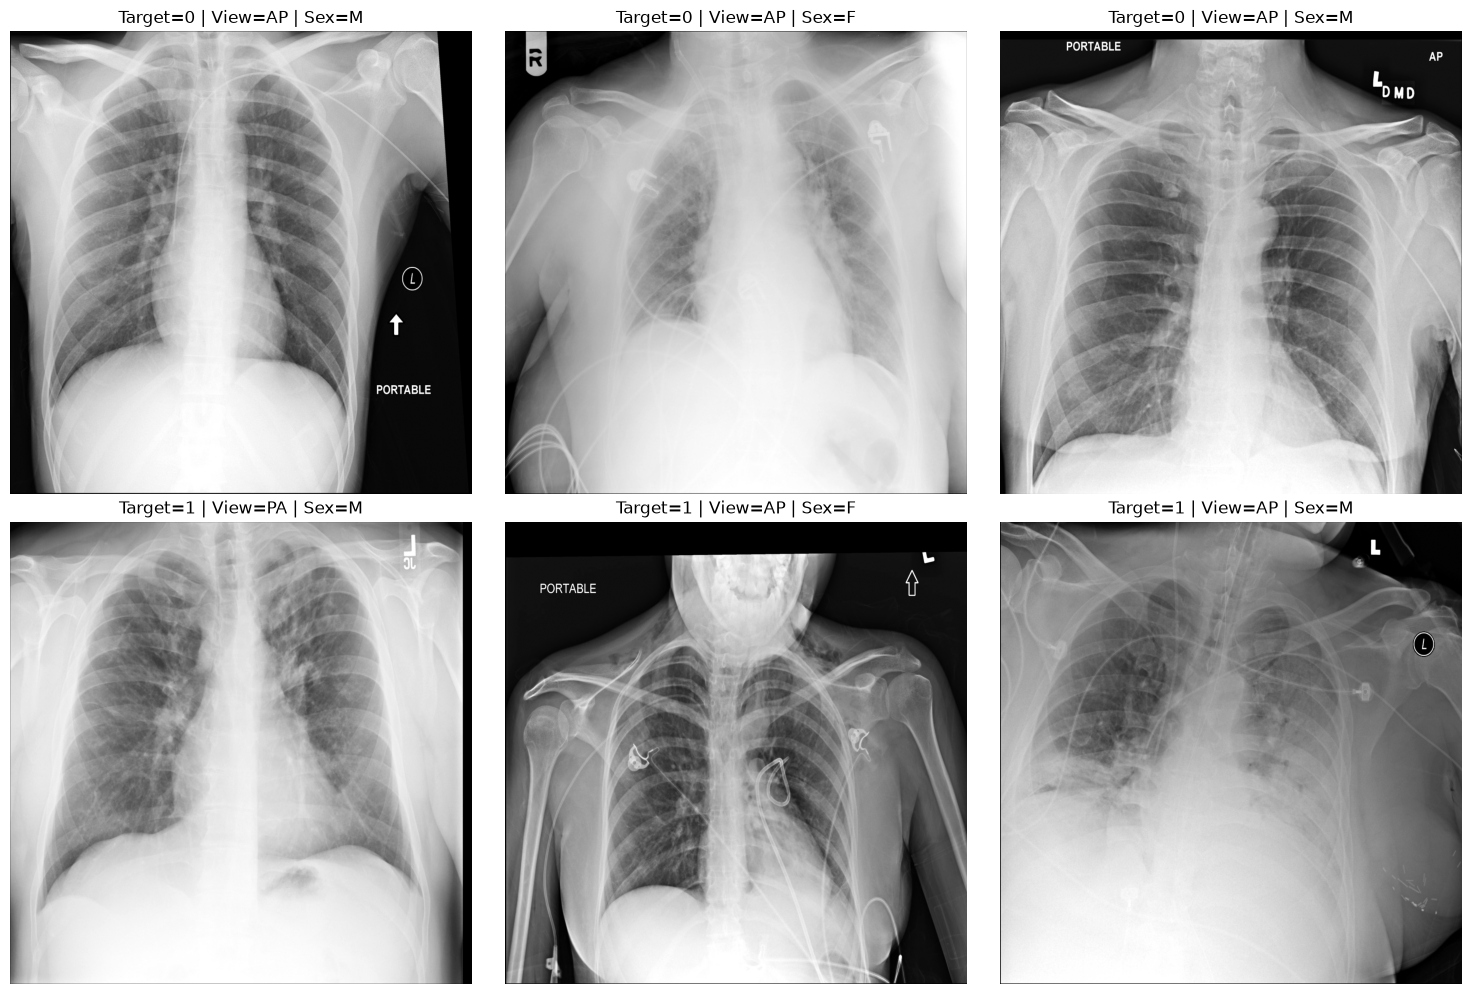

In [154]:
# 3 negative and 3 positive examples

examples = (
    dataset.groupby("Target", group_keys=False)
    .sample(n=3, random_state=42)
)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, row in zip(axes.flat, examples.itertuples()):
    dicom = pydicom.dcmread(row.dicom_path)
    image = dicom.pixel_array.astype(np.float32)

    if dicom.PhotometricInterpretation == "MONOCHROME1":
        image = image.max() + image.min() - image

    low, high = np.percentile(image, [1, 99])

    ax.imshow(image, cmap="gray", vmin=low, vmax=high)
    ax.set_title(
        f"Target={row.Target} | View={row.ViewPosition} | Sex={row.PatientSex}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [21]:
# smallest boxes = probably the hardest positives

positive_boxes = labels[labels["Target"] == 1].copy()
positive_boxes["box_area"] = positive_boxes["width"] * positive_boxes["height"]

smallest_per_exam = (
    positive_boxes.groupby("patientId")["box_area"]
    .min()
    .sort_values()
)

print(smallest_per_exam.head(10))

patientId
1.2.276.0.7230010.3.1.4.8323329.16205.1517874395.381849    2320.0
1.2.276.0.7230010.3.1.4.8323329.4424.1517874307.687895     2714.0
1.2.276.0.7230010.3.1.4.8323329.19503.1517874418.362597    3078.0
1.2.276.0.7230010.3.1.4.8323329.17779.1517874406.134125    3100.0
1.2.276.0.7230010.3.1.4.8323329.5934.1517874319.128937     3534.0
1.2.276.0.7230010.3.1.4.8323329.14472.1517874379.654391    3776.0
1.2.276.0.7230010.3.1.4.8323329.20085.1517874421.599120    4216.0
1.2.276.0.7230010.3.1.4.8323329.12940.1517874368.448796    4500.0
1.2.276.0.7230010.3.1.4.8323329.16277.1517874395.925554    5040.0
1.2.276.0.7230010.3.1.4.8323329.17473.1517874404.268359    5096.0
Name: box_area, dtype: float64


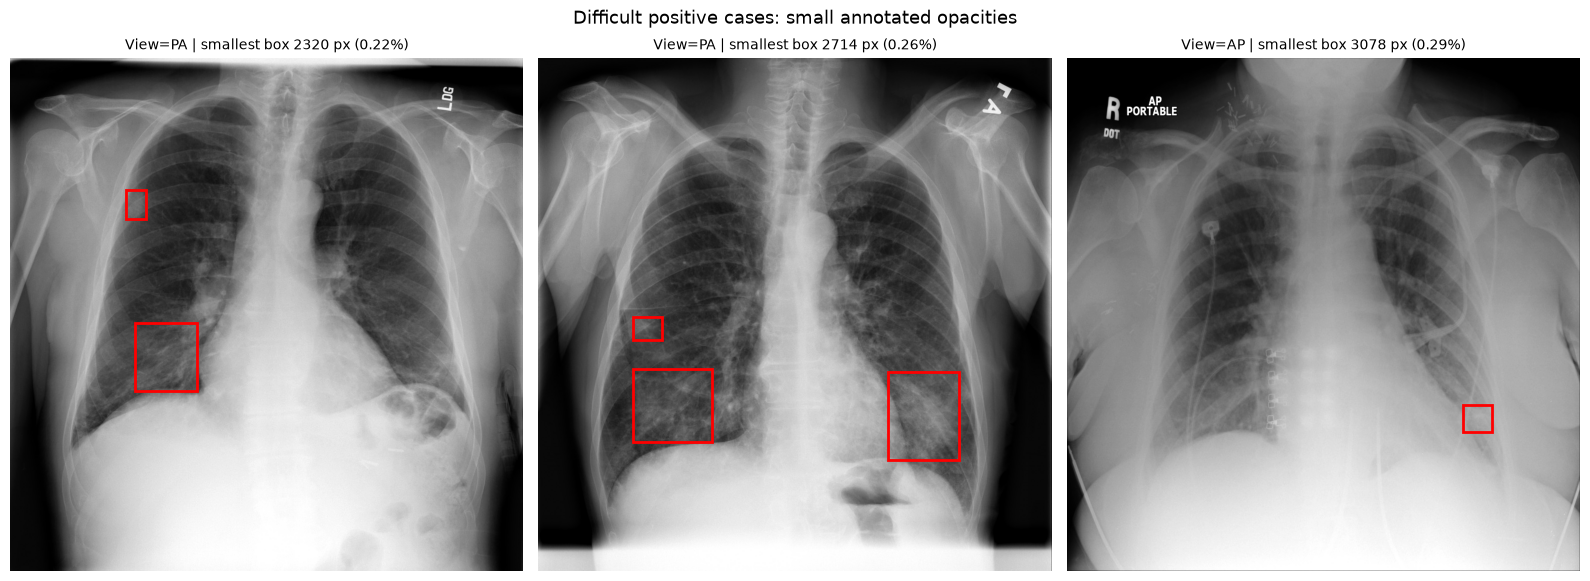

In [22]:
# difficult cases, the opacity box is tiny (less than 1% of the image)

hard_ids = smallest_per_exam.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, pid in zip(axes, hard_ids):
    row = dataset[dataset["patientId"] == pid].iloc[0]

    dicom = pydicom.dcmread(row["dicom_path"])
    image = dicom.pixel_array.astype(np.float32)

    low, high = np.percentile(image, [1, 99])
    ax.imshow(image, cmap="gray", vmin=low, vmax=high)

    boxes = labels[labels["patientId"] == pid]

    for box in boxes.itertuples():
        rect = plt.Rectangle(
            (box.x, box.y),
            box.width,
            box.height,
            fill=False,
            edgecolor="red",
            linewidth=2,
        )
        ax.add_patch(rect)

    area = boxes["width"].mul(boxes["height"]).min()
    percent = 100 * area / (dicom.Rows * dicom.Columns)

    ax.set_title(
        f"View={row['ViewPosition']} | smallest box {area:.0f} px ({percent:.2f}%)",
        fontsize=10,
    )
    ax.axis("off")

plt.suptitle("Difficult positive cases: small annotated opacities", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Patient-level train / validation / test split

In [28]:
# split by nih patient id 70/15/15, stratified
# test set not used again until the end

SEED = 31

patient_labels = (
    dataset.groupby("nih_patient_id", as_index=False)['Target'].max()
)

train_patients, remaining_patients = train_test_split(
    patient_labels,
    test_size=0.30,
    stratify=patient_labels["Target"],
    random_state=SEED,
)

val_patients, test_patients = train_test_split(
    remaining_patients,
    test_size=0.50,
    stratify=remaining_patients["Target"],
    random_state=SEED,
)

train_ids = set(train_patients["nih_patient_id"])
val_ids = set(val_patients["nih_patient_id"])
test_ids = set(test_patients["nih_patient_id"])

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

train_df = dataset[dataset["nih_patient_id"].isin(train_ids)].copy()
val_df = dataset[dataset["nih_patient_id"].isin(val_ids)].copy()
test_df = dataset[dataset["nih_patient_id"].isin(test_ids)].copy()

split_summary = pd.DataFrame(
    {
        "examinations": [len(train_df), len(val_df), len(test_df)],
        "source_patients": [len(train_ids), len(val_ids), len(test_ids)],
        "positive_proportion": [
            train_df["Target"].mean(),
            val_df["Target"].mean(),
            test_df["Target"].mean(),
        ],
    },
    index=["train", "validation", "test"],
)

display(split_summary)

,examinations,source_patients,positive_proportion
train,17822,7819,0.216250
validation,3942,1676,0.233638
test,3920,1676,0.225510


## 7. Trivial baseline

In [108]:
# trivial baseline, always predict the majority class (0)
# 0.77 accuracy but sensitivity is 0, accuracy is misleading here

majority_class = train_df["Target"].mode().iat[0]

y_val = val_df["Target"]
trivial_predictions = np.full(len(val_df), majority_class)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    trivial_predictions,
    labels=[0, 1],
).ravel()

trivial_baseline_metrics = pd.DataFrame(
    {
        "accuracy": [accuracy_score(y_val, trivial_predictions)],
        "sensitivity": [recall_score(y_val, trivial_predictions, zero_division=0)],
        "specificity": [tn / (tn + fp)],
        "precision": [
            precision_score(y_val, trivial_predictions, zero_division=0)
        ],
        "f1_score": [f1_score(y_val, trivial_predictions, zero_division=0)],
    },
    index=["Trivial baseline"],
)

print("Majority class predicted for every validation image:", majority_class)
display(trivial_baseline_metrics)

Majority class predicted for every validation image: 0


,accuracy,sensitivity,specificity,precision,f1_score
Trivial baseline,0.766362,0.0,1.0,0.0,0.0


## 8. Simple baseline: logistic regression on intensity features

In [72]:
# features for the simple baseline

FEATURE_COLUMNS = [
    "mean_intensity",
    "std_intensity",
    "p10_intensity",
    "p90_intensity",
]

def extract_summary_features(dicom_path):
    dicom = pydicom.dcmread(dicom_path)

    image = dicom.pixel_array.astype(np.float32)

    if dicom.PhotometricInterpretation == "MONOCHROME1":
        image = image.max() + image.min() - image

    return {
        "mean_intensity": image.mean(),
        "std_intensity": image.std(),
        "p10_intensity": np.percentile(image, 10),
        "p90_intensity": np.percentile(image, 90),
    }

example_features = extract_summary_features(train_df.iloc[0]["dicom_path"])

display(pd.Series(example_features))

mean_intensity    107.970535
std_intensity      55.825073
p10_intensity      10.000000
p90_intensity     185.000000
dtype: float32

In [70]:
# builds the feature table for a split (slow bc it reads every dicom)

from tqdm.auto import tqdm

def build_feature_table(split_df, split_name):
    feature_rows = []

    for row in tqdm(
        split_df.itertuples(),
        total=len(split_df),
        desc=f"Extracting {split_name} features",
    ):
        features = extract_summary_features(row.dicom_path)

        features["patientId"] = row.patientId
        features["nih_patient_id"] = row.nih_patient_id
        features["Target"] = row.Target

        feature_rows.append(features)

    return pd.DataFrame(feature_rows)

In [73]:
# takes ~8 min

train_features = build_feature_table(train_df, "train")
val_features = build_feature_table(val_df, "validation")

display(train_features.head())

assert train_features[FEATURE_COLUMNS].notna().all().all()
assert val_features[FEATURE_COLUMNS].notna().all().all()

Extracting validation features: 100%|██████████| 3942/3942 [01:25<00:00, 45.85it/s]


,mean_intensity,std_intensity,p10_intensity,p90_intensity,patientId,nih_patient_id,Target
0,107.970535,55.825073,10.0,185.0,1.2.276.0.7230010.3.1.4.8323329.10001.15178743...,11683,0
1,122.345673,56.435192,34.0,193.0,1.2.276.0.7230010.3.1.4.8323329.10004.15178743...,30355,0
2,115.405624,69.687553,17.0,219.0,1.2.276.0.7230010.3.1.4.8323329.10005.15178743...,14758,0
3,114.897240,74.822678,2.0,219.0,1.2.276.0.7230010.3.1.4.8323329.10006.15178743...,4082,0
4,114.879074,69.234207,15.0,210.0,1.2.276.0.7230010.3.1.4.8323329.10007.15178743...,15852,0


In [74]:
# scaler fit on train only

X_train = train_features[FEATURE_COLUMNS]
y_train = train_features["Target"]

X_val = val_features[FEATURE_COLUMNS]
y_val = val_features["Target"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

assert np.isfinite(X_train_scaled).all()
assert np.isfinite(X_val_scaled).all()

In [113]:
# logistic regression = nn.Linear + BCEWithLogitsLoss

torch.manual_seed(SEED)

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32,
    device=device,
)

y_train_tensor = torch.tensor(
    y_train.to_numpy(),
    dtype=torch.float32,
    device=device,
).unsqueeze(1)

X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32,
    device=device,
)

y_val_tensor = torch.tensor(
    y_val.to_numpy(),
    dtype=torch.float32,
    device=device,
).unsqueeze(1)

baseline_model = torch.nn.Linear(
    in_features=len(FEATURE_COLUMNS),
    out_features=1,
).to(device)

loss_function = torch.nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    baseline_model.parameters(),
    lr=1e-3,
)

In [114]:
# train baseline for 30 epochs

from torch.utils.data import DataLoader, TensorDataset

BATCH_SIZE = 128
EPOCHS = 30

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    baseline_model.train()

    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        logits = baseline_model(X_batch)
        loss = loss_function(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * len(X_batch)

    average_train_loss = total_train_loss / len(train_dataset)

    baseline_model.eval()

    with torch.no_grad():
        val_logits = baseline_model(X_val_tensor)
        val_loss = loss_function(val_logits, y_val_tensor).item()

    train_losses.append(average_train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"Train loss: {average_train_loss:.4f} | "
        f"Validation loss: {val_loss:.4f}"
    )

Epoch 01/30 | Train loss: 0.6076 | Validation loss: 0.5943
Epoch 02/30 | Train loss: 0.5762 | Validation loss: 0.5754
Epoch 03/30 | Train loss: 0.5576 | Validation loss: 0.5620
Epoch 04/30 | Train loss: 0.5440 | Validation loss: 0.5523
Epoch 05/30 | Train loss: 0.5340 | Validation loss: 0.5452
Epoch 06/30 | Train loss: 0.5265 | Validation loss: 0.5400
Epoch 07/30 | Train loss: 0.5211 | Validation loss: 0.5367
Epoch 08/30 | Train loss: 0.5173 | Validation loss: 0.5346
Epoch 09/30 | Train loss: 0.5147 | Validation loss: 0.5334
Epoch 10/30 | Train loss: 0.5129 | Validation loss: 0.5325
Epoch 11/30 | Train loss: 0.5116 | Validation loss: 0.5320
Epoch 12/30 | Train loss: 0.5108 | Validation loss: 0.5318
Epoch 13/30 | Train loss: 0.5102 | Validation loss: 0.5316
Epoch 14/30 | Train loss: 0.5099 | Validation loss: 0.5317
Epoch 15/30 | Train loss: 0.5097 | Validation loss: 0.5317
Epoch 16/30 | Train loss: 0.5095 | Validation loss: 0.5316
Epoch 17/30 | Train loss: 0.5093 | Validation loss: 0.53

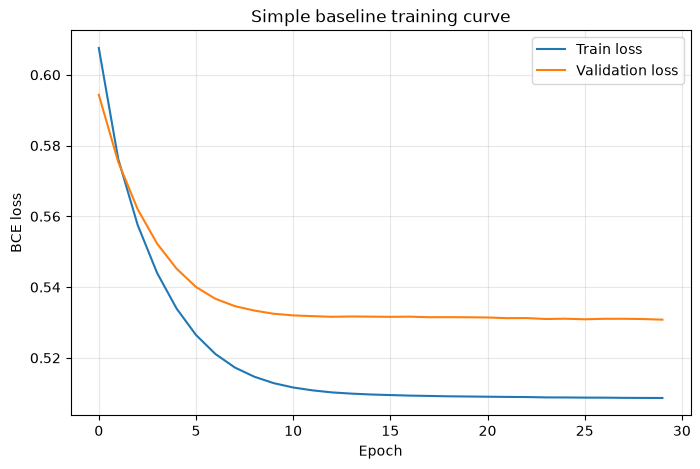

In [115]:
# baseline loss curve

plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Simple baseline training curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [116]:
# at 0.5 it predicts 0 for everything, same as the trivial baseline

with torch.no_grad():
    val_logits = baseline_model(X_val_tensor)

val_probabilities = torch.sigmoid(val_logits).squeeze(1).cpu().numpy()
val_predictions = (val_probabilities >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(
    y_val,
    val_predictions,
    labels=[0, 1],
).ravel()

simple_baseline_metrics = pd.DataFrame(
    {
        "accuracy": [accuracy_score(y_val, val_predictions)],
        "sensitivity": [recall_score(y_val, val_predictions, zero_division=0)],
        "specificity": [tn / (tn + fp)],
        "precision": [precision_score(y_val, val_predictions, zero_division=0)],
        "f1_score": [f1_score(y_val, val_predictions, zero_division=0)],
    },
    index=["Simple logistic baseline"],
)

display(simple_baseline_metrics)

,accuracy,sensitivity,specificity,precision,f1_score
Simple logistic baseline,0.766362,0.0,1.0,0.0,0.0


## 9. Class weighting for the simple baseline

In [40]:
# helper functions (probabilities + metrics), used a lot later

def predict_probabilities(model, X_tensor):
    model.eval()

    with torch.no_grad():
        logits = model(X_tensor)

    return torch.sigmoid(logits).squeeze(1).cpu().numpy()


def binary_metrics(y_true, probabilities, threshold=0.5):
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1],
    ).ravel()

    return {
        "accuracy": accuracy_score(y_true, predictions),
        "sensitivity": recall_score(y_true, predictions, zero_division=0),
        "specificity": tn / (tn + fp),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "f1_score": f1_score(y_true, predictions, zero_division=0),
    }

In [118]:
# unweighted baseline metrics to compare with below

unweighted_val_probabilities = predict_probabilities(
    baseline_model,
    X_val_tensor,
)

unweighted_metrics = binary_metrics(
    y_val,
    unweighted_val_probabilities,
)

In [119]:
# extra, not required: the brief only needs the with/without weighting test on the cnn, I did it on the baseline too because the unweighted one predicts all negatives and is useless to compare with
# weighted version, pos_weight = neg/pos (~3.6)

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

pos_weight = torch.tensor(
    [negative_count / positive_count],
    dtype=torch.float32,
    device=device,
)

torch.manual_seed(SEED)

weighted_model = torch.nn.Linear(
    in_features=len(FEATURE_COLUMNS),
    out_features=1,
).to(device)

weighted_loss_function = torch.nn.BCEWithLogitsLoss(
    pos_weight=pos_weight,
)

weighted_optimizer = torch.optim.Adam(
    weighted_model.parameters(),
    lr=1e-3,
)

weighted_train_losses = []
weighted_val_losses = []

for epoch in range(EPOCHS):
    weighted_model.train()

    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        weighted_optimizer.zero_grad()

        logits = weighted_model(X_batch)
        loss = weighted_loss_function(logits, y_batch)

        loss.backward()
        weighted_optimizer.step()

        total_train_loss += loss.item() * len(X_batch)

    average_train_loss = total_train_loss / len(train_dataset)

    weighted_model.eval()

    with torch.no_grad():
        val_logits = weighted_model(X_val_tensor)
        val_loss = weighted_loss_function(
            val_logits,
            y_val_tensor,
        ).item()

    weighted_train_losses.append(average_train_loss)
    weighted_val_losses.append(val_loss)

In [120]:
# extra (part of the weighted baseline check above)
# weighting fixes it, sensitivity 0 -> 0.58
# accuracy goes down but that's ok

weighted_val_probabilities = predict_probabilities(
    weighted_model,
    X_val_tensor,
)

weighted_metrics = binary_metrics(
    y_val,
    weighted_val_probabilities,
)

baseline_comparison = pd.DataFrame(
    [unweighted_metrics, weighted_metrics],
    index=[
        "Simple baseline - unweighted",
        "Simple baseline - weighted",
    ],
)

display(baseline_comparison)

,accuracy,sensitivity,specificity,precision,f1_score
Simple baseline - unweighted,0.766362,0.000000,1.000000,0.000000,0.000000
Simple baseline - weighted,0.651446,0.577633,0.673949,0.350692,0.436423


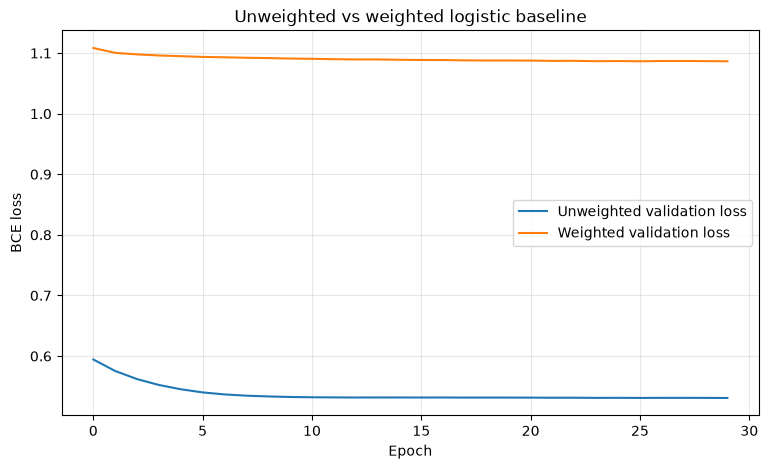

In [121]:
# extra (part of the weighted baseline check above)
# val loss unweighted vs weighted (different scale, only compare the shape)

plt.figure(figsize=(9, 5))

plt.plot(
    val_losses,
    label="Unweighted validation loss",
)

plt.plot(
    weighted_val_losses,
    label="Weighted validation loss",
)

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("Unweighted vs weighted logistic baseline")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 10. Baselines on the test set

In [66]:
# trivial baseline on test (majority class taken from train)
# roc auc is 0.5 and pr auc = prevalence since every image gets the same score

trivial_class = train_df["Target"].mode().iat[0]

trivial_test_predictions = np.full(len(test_df), trivial_class)
y_test_true = test_df["Target"].to_numpy()

tn, fp, fn, tp = confusion_matrix(
    y_test_true,
    trivial_test_predictions,
    labels=[0, 1],
).ravel()

trivial_test_metrics = {
    "accuracy": accuracy_score(y_test_true, trivial_test_predictions),
    "sensitivity": recall_score(y_test_true, trivial_test_predictions, zero_division=0),
    "specificity": tn / (tn + fp),
    "precision": precision_score(y_test_true, trivial_test_predictions, zero_division=0),
    "f1_score": f1_score(y_test_true, trivial_test_predictions, zero_division=0),
    "roc_auc": 0.5,
    "pr_auc": y_test_true.mean(),
}

print("Majority class from TRAIN:", trivial_class)
display(pd.DataFrame([trivial_test_metrics], index=["Trivial baseline (test)"]))

Majority class from TRAIN: 0


,accuracy,sensitivity,specificity,precision,f1_score,roc_auc,pr_auc
Trivial baseline (test),0.77449,0.0,1.0,0.0,0.0,0.5,0.22551


In [ ]:
# weighted baseline on the test set, only run once

test_features = build_feature_table(test_df, "test")

X_test = test_features[FEATURE_COLUMNS]
y_test = test_features["Target"]

X_test_scaled = scaler.transform(X_test)

assert np.isfinite(X_test_scaled).all()

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32,
    device=device,
)

weighted_test_probabilities = predict_probabilities(
    weighted_model,
    X_test_tensor,
)

weighted_test_predictions = (
    weighted_test_probabilities >= 0.5
).astype(int)

weighted_test_metrics = pd.DataFrame(
    [binary_metrics(y_test, weighted_test_probabilities)],
    index=["Simple baseline - weighted test"],
)

test_confusion_matrix = pd.DataFrame(
    confusion_matrix(
        y_test,
        weighted_test_predictions,
        labels=[0, 1],
    ),
    index=["Actual negative", "Actual positive"],
    columns=["Predicted negative", "Predicted positive"],
)

display(weighted_test_metrics)
display(test_confusion_matrix)

In [ ]:
# roc auc / pr auc for the simple baseline, for the final table

from sklearn.metrics import roc_auc_score, average_precision_score

simple_test_metrics = binary_metrics(y_test, weighted_test_probabilities)

simple_test_metrics["roc_auc"] = roc_auc_score(y_test, weighted_test_probabilities)
simple_test_metrics["pr_auc"] = average_precision_score(y_test, weighted_test_probabilities)

display(pd.DataFrame([simple_test_metrics], index=["Simple baseline (test)"]))

## 11. Image preprocessing

In [23]:
# imports for the cnn part

from pydicom.pixels import apply_modality_lut
import torch.nn.functional as F

from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

In [26]:
# preprocessing: modality lut, invert if MONOCHROME1, clip 1-99 percentile, scale to 0-1
# then resize 224, repeat to 3 channels and imagenet normalize (pretrained models expect 3 ch)

IMAGE_SIZE = 224
CLIP_LOW = 1
CLIP_HIGH = 99

IMAGENET_MEAN = torch.tensor(
    [0.485, 0.456, 0.406],
    dtype=torch.float32,
).view(3, 1, 1)

IMAGENET_STD = torch.tensor(
    [0.229, 0.224, 0.225],
    dtype=torch.float32,
).view(3, 1, 1)


def load_normalized_dicom(dicom_path):
    dicom = pydicom.dcmread(dicom_path)

    raw_pixels = dicom.pixel_array
    padding_value = getattr(dicom, "PixelPaddingValue", None)

    if padding_value is None:
        padding_mask = np.zeros(raw_pixels.shape, dtype=bool)
    else:
        padding_mask = raw_pixels == padding_value

    image = apply_modality_lut(raw_pixels, dicom).astype(np.float32)

    if dicom.PhotometricInterpretation == "MONOCHROME1":
        valid_pixels = image[~padding_mask]
        image = valid_pixels.min() + valid_pixels.max() - image

    valid_pixels = image[~padding_mask]

    low, high = np.percentile(
        valid_pixels,
        [CLIP_LOW, CLIP_HIGH],
    )

    image = np.clip(image, low, high)
    image = (image - low) / (high - low + 1e-8)

    image[padding_mask] = 0.0

    return image.astype(np.float32)


def dicom_to_image_tensor(dicom_path):
    image = load_normalized_dicom(dicom_path)

    tensor = torch.from_numpy(image).to(torch.float32)
    tensor = tensor.unsqueeze(0).unsqueeze(0)

    tensor = F.interpolate(
        tensor,
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="bilinear",
        align_corners=False,
    )

    return tensor.squeeze(0).repeat(3, 1, 1)


def normalize_for_imagenet(tensor):
    return ((tensor - IMAGENET_MEAN) / IMAGENET_STD).to(torch.float32)


def preprocess_for_cnn(dicom_path, augmentation=None):
    tensor = dicom_to_image_tensor(dicom_path)

    if augmentation is not None:
        tensor = augmentation(tensor.to(torch.float32))

    return normalize_for_imagenet(tensor)

In [29]:
# sanity check on one image

sample_tensor = preprocess_for_cnn(
    train_df.iloc[0]["dicom_path"]
)

print("Tensor shape:", sample_tensor.shape)
print("Minimum value:", sample_tensor.min().item())
print("Maximum value:", sample_tensor.max().item())

Tensor shape: torch.Size([3, 224, 224])
Minimum value: -2.1179039478302
Maximum value: 2.640000104904175


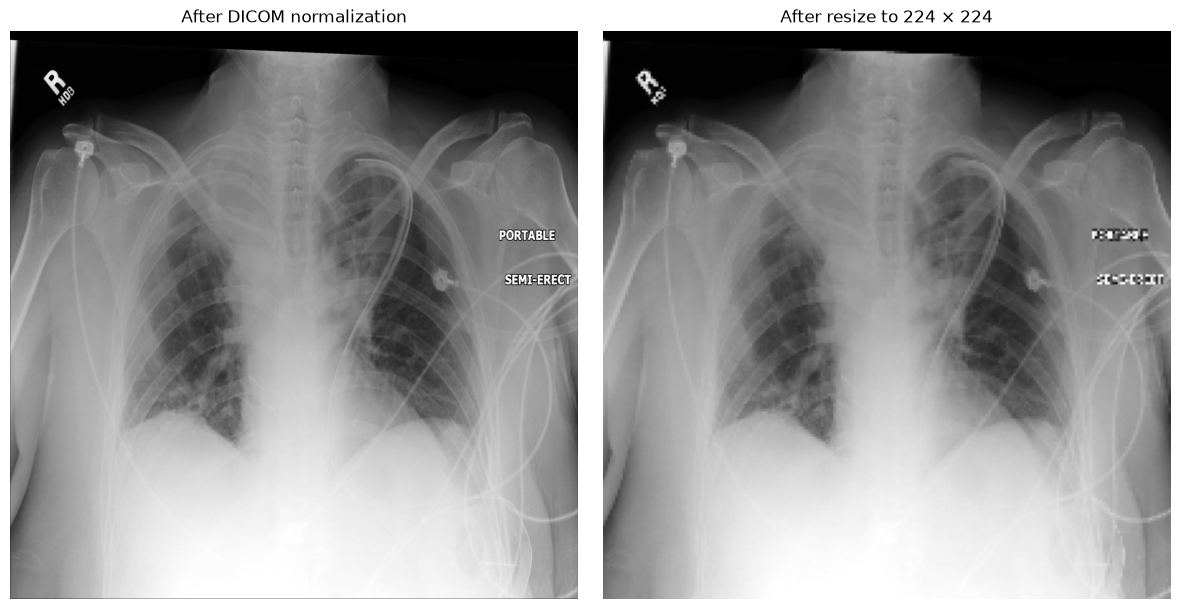

In [30]:
# before / after preprocessing

sample_path = train_df.iloc[0]["dicom_path"]

before_image = load_normalized_dicom(sample_path)

after_tensor = preprocess_for_cnn(sample_path)

after_tensor = (
    after_tensor * IMAGENET_STD
    + IMAGENET_MEAN
)

after_image = after_tensor[0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(before_image, cmap="gray")
axes[0].set_title("After DICOM normalization")
axes[0].axis("off")

axes[1].imshow(after_image, cmap="gray")
axes[1].set_title("After resize to 224 × 224")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 12. Data augmentation (train only)

In [31]:
# augmentation for train only, small rotation + shift
# no horizontal flip, the heart would end up on the wrong side

TRAIN_AUGMENTATION = transforms.RandomAffine(
    degrees=7,
    translate=(0.03, 0.03),
    interpolation=transforms.InterpolationMode.BILINEAR,
    fill=0.0,
)

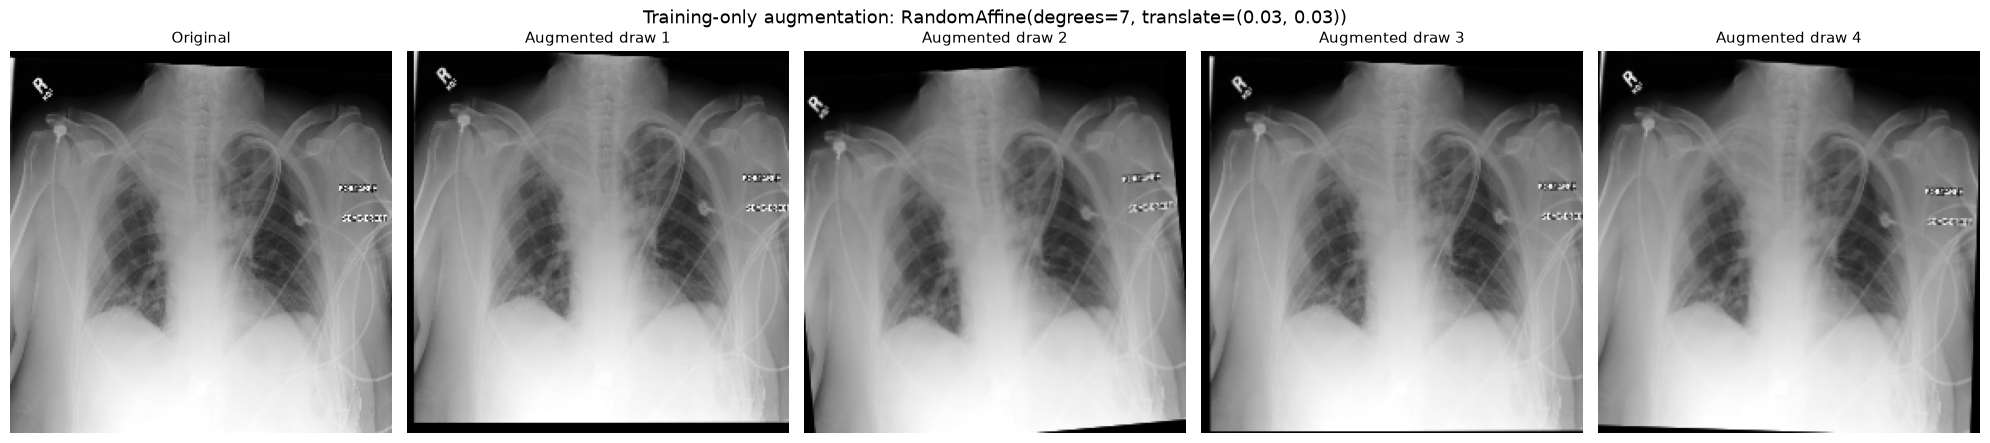

In [ ]:
# before/after augmentation panel

augmentation_example_path = train_df.iloc[0]["dicom_path"]
original_image = dicom_to_image_tensor(augmentation_example_path)

torch.manual_seed(0)

fig, axes = plt.subplots(1, 5, figsize=(20, 4.5))

axes[0].imshow(original_image[0].numpy(), cmap="gray")
axes[0].set_title("Original", fontsize=11)
axes[0].axis("off")

for i in range(1, 5):
    augmented = TRAIN_AUGMENTATION(original_image)
    axes[i].imshow(augmented[0].numpy(), cmap="gray")
    axes[i].set_title(f"Augmented draw {i}", fontsize=11)
    axes[i].axis("off")

plt.suptitle(
    "Training-only augmentation: RandomAffine(degrees=7, translate=(0.03, 0.03))",
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 13. Dataset and data loaders

In [32]:
# dataset class

class ChestXrayDataset(Dataset):
    def __init__(self, dataframe, augmentation=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augmentation = augmentation

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        image = preprocess_for_cnn(
            row["dicom_path"],
            augmentation=self.augmentation,
        )

        label = torch.tensor(
            [row["Target"]],
            dtype=torch.float32,
        )

        return image, label

In [33]:
# dataloaders, only train is shuffled

CNN_BATCH_SIZE = 32

cnn_train_dataset = ChestXrayDataset(
    train_df,
    augmentation=TRAIN_AUGMENTATION,
)

cnn_val_dataset = ChestXrayDataset(
    val_df,
    augmentation=None,
)

cnn_train_loader = DataLoader(
    cnn_train_dataset,
    batch_size=CNN_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

cnn_val_loader = DataLoader(
    cnn_val_dataset,
    batch_size=CNN_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

In [34]:
# check one batch

images, labels = next(iter(cnn_train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32, 1])
Image dtype: torch.float32
Label dtype: torch.float32


## 14. First CNN: frozen ResNet18

In [35]:
# resnet18

from torchvision.models import ResNet18_Weights, resnet18

In [38]:
# pretrained resnet18, freeze everything and new fc with 1 output
# fixed feature extractor first

CNN_SEED = 42
CNN_EPOCHS = 10
CNN_LEARNING_RATE = 1e-3

torch.manual_seed(CNN_SEED)

resnet_weights = ResNet18_Weights.DEFAULT

cnn_model = resnet18(
    weights=resnet_weights,
)

for parameter in cnn_model.parameters():
    parameter.requires_grad = False

input_features = cnn_model.fc.in_features

cnn_model.fc = torch.nn.Linear(
    input_features,
    1,
)

cnn_model = cnn_model.to(device)

cnn_loss_function = torch.nn.BCEWithLogitsLoss()

cnn_optimizer = torch.optim.Adam(
    cnn_model.fc.parameters(),
    lr=CNN_LEARNING_RATE,
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\11/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:05<00:00, 8.32MB/s]


In [134]:
# train only the fc layer, 10 epochs

cnn_train_losses = []
cnn_val_losses = []

for epoch in range(CNN_EPOCHS):
    cnn_model.eval()
    cnn_model.fc.train()

    total_train_loss = 0.0

    for images, labels in cnn_train_loader:
        images = images.to(device)
        labels = labels.to(device)

        cnn_optimizer.zero_grad()

        logits = cnn_model(images)
        loss = cnn_loss_function(logits, labels)

        loss.backward()
        cnn_optimizer.step()

        total_train_loss += loss.item() * images.size(0)

    average_train_loss = total_train_loss / len(cnn_train_dataset)

    cnn_model.eval()

    total_val_loss = 0.0

    with torch.no_grad():
        for images, labels in cnn_val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = cnn_model(images)
            loss = cnn_loss_function(logits, labels)

            total_val_loss += loss.item() * images.size(0)

    average_val_loss = total_val_loss / len(cnn_val_dataset)

    cnn_train_losses.append(average_train_loss)
    cnn_val_losses.append(average_val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{CNN_EPOCHS} | "
        f"Train loss: {average_train_loss:.4f} | "
        f"Validation loss: {average_val_loss:.4f}"
    )

Epoch 01/10 | Train loss: 0.4203 | Validation loss: 0.4104
Epoch 02/10 | Train loss: 0.3982 | Validation loss: 0.4160
Epoch 03/10 | Train loss: 0.3954 | Validation loss: 0.4101
Epoch 04/10 | Train loss: 0.3947 | Validation loss: 0.4089
Epoch 05/10 | Train loss: 0.3928 | Validation loss: 0.3976
Epoch 06/10 | Train loss: 0.3919 | Validation loss: 0.4057
Epoch 07/10 | Train loss: 0.3902 | Validation loss: 0.3964
Epoch 08/10 | Train loss: 0.3899 | Validation loss: 0.3954
Epoch 09/10 | Train loss: 0.3894 | Validation loss: 0.3940
Epoch 10/10 | Train loss: 0.3879 | Validation loss: 0.4001


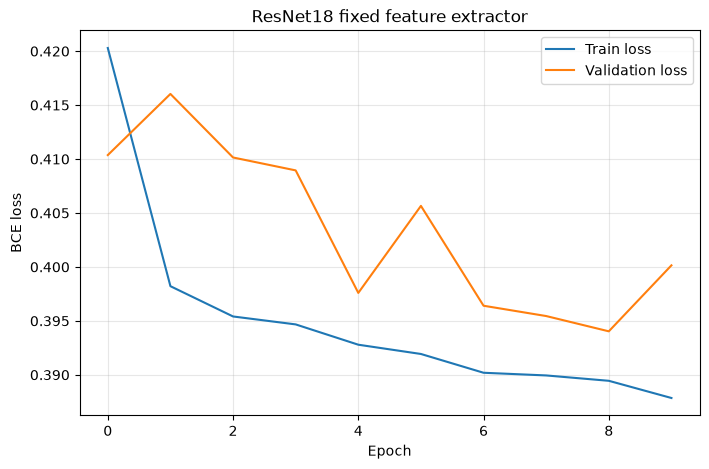

In [135]:
# loss curve (frozen)

plt.figure(figsize=(8, 5))

plt.plot(cnn_train_losses, label="Train loss")
plt.plot(cnn_val_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("BCE loss")
plt.title("ResNet18 fixed feature extractor")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [36]:
# get probs + labels from a loader

def predict_cnn_probabilities(model, data_loader):
    model.eval()

    all_probabilities = []
    all_targets = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device, dtype=torch.float32)

            logits = model(images)
            probabilities = torch.sigmoid(logits)

            all_probabilities.append(
                probabilities.squeeze(1).cpu().numpy()
            )

            all_targets.append(
                labels.squeeze(1).numpy()
            )

    return (
        np.concatenate(all_probabilities),
        np.concatenate(all_targets),
    )

In [54]:
# frozen resnet val metrics (no weighting)

fixed_val_probabilities, fixed_val_targets = (
    predict_cnn_probabilities(
        cnn_model,
        cnn_val_loader,
    )
)

fixed_cnn_metrics = pd.DataFrame(
    [binary_metrics(fixed_val_targets, fixed_val_probabilities)],
    index=["ResNet18 fixed extractor"],
)

display(fixed_cnn_metrics)

,accuracy,sensitivity,specificity,precision,f1_score
ResNet18 fixed extractor,0.68899,0.20304,0.83714,0.275405,0.23375


## 15. Adding class weights to the CNN

In [45]:
# same thing but with the weighted loss

train_negative_count = (train_df["Target"] == 0).sum()
train_positive_count = (train_df["Target"] == 1).sum()

cnn_pos_weight = torch.tensor(
    [train_negative_count / train_positive_count],
    dtype=torch.float32,
    device=device,
)

torch.manual_seed(CNN_SEED)

weighted_cnn_model = resnet18(
    weights=ResNet18_Weights.DEFAULT,
)

for parameter in weighted_cnn_model.parameters():
    parameter.requires_grad = False

weighted_cnn_model.fc = torch.nn.Linear(
    weighted_cnn_model.fc.in_features,
    1,
)

weighted_cnn_model = weighted_cnn_model.to(device)

weighted_cnn_loss_function = torch.nn.BCEWithLogitsLoss(
    pos_weight=cnn_pos_weight,
)

weighted_cnn_optimizer = torch.optim.Adam(
    weighted_cnn_model.fc.parameters(),
    lr=CNN_LEARNING_RATE,
)

In [140]:
# train the weighted frozen resnet
# loss is higher because of pos_weight, that's expected

weighted_cnn_train_losses = []
weighted_cnn_val_losses = []

for epoch in range(CNN_EPOCHS):
    weighted_cnn_model.eval()
    weighted_cnn_model.fc.train()

    total_train_loss = 0.0

    for images, labels in cnn_train_loader:
        images = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.float32)

        weighted_cnn_optimizer.zero_grad()

        logits = weighted_cnn_model(images)

        loss = weighted_cnn_loss_function(
            logits,
            labels,
        )

        loss.backward()
        weighted_cnn_optimizer.step()

        total_train_loss += loss.item() * images.size(0)

    average_train_loss = total_train_loss / len(cnn_train_dataset)

    weighted_cnn_model.eval()

    total_val_loss = 0.0

    with torch.no_grad():
        for images, labels in cnn_val_loader:
            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.float32)

            logits = weighted_cnn_model(images)

            loss = weighted_cnn_loss_function(
                logits,
                labels,
            )

            total_val_loss += loss.item() * images.size(0)

    average_val_loss = total_val_loss / len(cnn_val_dataset)

    weighted_cnn_train_losses.append(average_train_loss)
    weighted_cnn_val_losses.append(average_val_loss)

    print(
        f"Epoch {epoch + 1:02d}/{CNN_EPOCHS} | "
        f"Train loss: {average_train_loss:.4f} | "
        f"Validation loss: {average_val_loss:.4f}"
    )

Epoch 01/10 | Train loss: 0.8522 | Validation loss: 0.8195
Epoch 02/10 | Train loss: 0.8038 | Validation loss: 0.8666
Epoch 03/10 | Train loss: 0.7976 | Validation loss: 0.8259
Epoch 04/10 | Train loss: 0.7983 | Validation loss: 0.8074
Epoch 05/10 | Train loss: 0.7902 | Validation loss: 0.8009
Epoch 06/10 | Train loss: 0.7901 | Validation loss: 0.8190
Epoch 07/10 | Train loss: 0.7858 | Validation loss: 0.7901
Epoch 08/10 | Train loss: 0.7844 | Validation loss: 0.7864
Epoch 09/10 | Train loss: 0.7820 | Validation loss: 0.7835
Epoch 10/10 | Train loss: 0.7795 | Validation loss: 0.7888


In [141]:
# unweighted vs weighted cnn, sensitivity goes up a lot and precision drops

weighted_val_probabilities, weighted_val_targets = (
    predict_cnn_probabilities(
        weighted_cnn_model,
        cnn_val_loader,
    )
)

weighted_fixed_cnn_metrics = pd.DataFrame(
    [binary_metrics(weighted_val_targets, weighted_val_probabilities)],
    index=["ResNet18 fixed extractor - weighted"],
)

comparison = pd.concat(
    [fixed_cnn_metrics, weighted_fixed_cnn_metrics],
)

display(comparison)

,accuracy,sensitivity,specificity,precision,f1_score
ResNet18 fixed extractor,0.817098,0.363735,0.955313,0.712766,0.481668
ResNet18 fixed extractor - weighted,0.764333,0.745928,0.769944,0.497106,0.596613


## 16. Fine-tuning and trying other backbones

In [58]:
# training loop with early stopping on val PR-AUC (patience 3)
# using pr-auc because the data is imbalanced

import copy

from sklearn.metrics import average_precision_score
from torchvision.models import (
    DenseNet121_Weights,
    EfficientNet_B0_Weights,
    densenet121,
    efficientnet_b0,
)


def train_with_pr_auc_checkpoint(
    model,
    trainable_module,
    optimizer,
    loss_function,
    epochs,
    run_name,
    patience=3,
):
    train_loss_history = []
    val_loss_history = []
    val_pr_auc_history = []

    best_pr_auc = -float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.eval()
        trainable_module.train()

        total_train_loss = 0.0

        for images, labels in cnn_train_loader:
            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.float32)

            optimizer.zero_grad()

            logits = model(images)
            loss = loss_function(logits, labels)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * images.size(0)

        average_train_loss = total_train_loss / len(cnn_train_dataset)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for images, labels in cnn_val_loader:
                images = images.to(device, dtype=torch.float32)
                labels = labels.to(device, dtype=torch.float32)

                logits = model(images)
                loss = loss_function(logits, labels)

                total_val_loss += loss.item() * images.size(0)

        average_val_loss = total_val_loss / len(cnn_val_dataset)

        val_probabilities, val_targets = predict_cnn_probabilities(
            model,
            cnn_val_loader,
        )

        val_pr_auc = average_precision_score(
            val_targets,
            val_probabilities,
        )

        train_loss_history.append(average_train_loss)
        val_loss_history.append(average_val_loss)
        val_pr_auc_history.append(val_pr_auc)

        print(
            f"{run_name} | Epoch {epoch + 1:02d}/{epochs} | "
            f"Train loss: {average_train_loss:.4f} | "
            f"Val loss: {average_val_loss:.4f} | "
            f"Val PR-AUC: {val_pr_auc:.4f}"
        )

        if val_pr_auc > best_pr_auc:
            best_pr_auc = val_pr_auc
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    model.load_state_dict(best_state)

    return {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "val_pr_auc": val_pr_auc_history,
        "best_pr_auc": best_pr_auc,
    }


def validation_result(model, model_name):
    probabilities, targets = predict_cnn_probabilities(
        model,
        cnn_val_loader,
    )

    metrics = binary_metrics(targets, probabilities)
    metrics["pr_auc"] = average_precision_score(
        targets,
        probabilities,
    )
    metrics["model"] = model_name

    return metrics

In [22]:
# fine tune layer4 + fc with a lower lr
# best at epoch 2 then it starts overfitting

for parameter in weighted_cnn_model.layer4.parameters():
    parameter.requires_grad = True

for parameter in weighted_cnn_model.fc.parameters():
    parameter.requires_grad = True

resnet_finetune_module = torch.nn.ModuleList(
    [
        weighted_cnn_model.layer4,
        weighted_cnn_model.fc,
    ]
)

resnet_finetune_optimizer = torch.optim.Adam(
    [
        {
            "params": weighted_cnn_model.layer4.parameters(),
            "lr": 1e-4,
        },
        {
            "params": weighted_cnn_model.fc.parameters(),
            "lr": 3e-4,
        },
    ],
    weight_decay=1e-4,
)

resnet_finetune_history = train_with_pr_auc_checkpoint(
    model=weighted_cnn_model,
    trainable_module=resnet_finetune_module,
    optimizer=resnet_finetune_optimizer,
    loss_function=weighted_cnn_loss_function,
    epochs=15,
    run_name="ResNet18 fine-tune",
)

ResNet18 fine-tune | Epoch 01/15 | Train loss: 0.8215 | Val loss: 0.8744 | Val PR-AUC: 0.6771


ResNet18 fine-tune | Epoch 02/15 | Train loss: 0.7155 | Val loss: 0.7594 | Val PR-AUC: 0.7027


ResNet18 fine-tune | Epoch 03/15 | Train loss: 0.6528 | Val loss: 0.8428 | Val PR-AUC: 0.6930


ResNet18 fine-tune | Epoch 04/15 | Train loss: 0.6026 | Val loss: 0.8526 | Val PR-AUC: 0.6754


ResNet18 fine-tune | Epoch 05/15 | Train loss: 0.5317 | Val loss: 0.9139 | Val PR-AUC: 0.6621
Early stopping at epoch 5


### Optional: other backbones

Not required by the brief. Just an extra check that fine-tuning ResNet18 is a reasonable pick compared to two other frozen ImageNet backbones.

In [24]:
# extra, not required: I tried two other pretrained backbones to check that resnet18 was a fair choice and not just the first one I picked
# densenet121 and efficientnet-b0 (frozen) to compare

def build_frozen_densenet121():
    torch.manual_seed(CNN_SEED)

    model = densenet121(
        weights=DenseNet121_Weights.DEFAULT,
    )

    for parameter in model.parameters():
        parameter.requires_grad = False

    model.classifier = torch.nn.Linear(
        model.classifier.in_features,
        1,
    )

    model = model.to(device)

    return model, model.classifier


def build_frozen_efficientnet_b0():
    torch.manual_seed(CNN_SEED)

    model = efficientnet_b0(
        weights=EfficientNet_B0_Weights.DEFAULT,
    )

    for parameter in model.parameters():
        parameter.requires_grad = False

    model.classifier[1] = torch.nn.Linear(
        model.classifier[1].in_features,
        1,
    )

    model = model.to(device)

    return model, model.classifier

In [25]:
# extra (other backbones comparison)
# densenet, head only

densenet_model, densenet_head = build_frozen_densenet121()

densenet_optimizer = torch.optim.Adam(
    densenet_head.parameters(),
    lr=1e-3,
)

densenet_history = train_with_pr_auc_checkpoint(
    model=densenet_model,
    trainable_module=densenet_head,
    optimizer=densenet_optimizer,
    loss_function=weighted_cnn_loss_function,
    epochs=10,
    run_name="DenseNet121 frozen",
)

DenseNet121 frozen | Epoch 01/10 | Train loss: 0.8569 | Val loss: 0.8319 | Val PR-AUC: 0.5923


DenseNet121 frozen | Epoch 02/10 | Train loss: 0.8044 | Val loss: 0.8143 | Val PR-AUC: 0.6200


DenseNet121 frozen | Epoch 03/10 | Train loss: 0.7973 | Val loss: 0.8111 | Val PR-AUC: 0.6234


DenseNet121 frozen | Epoch 04/10 | Train loss: 0.7876 | Val loss: 0.7989 | Val PR-AUC: 0.6307


DenseNet121 frozen | Epoch 05/10 | Train loss: 0.7824 | Val loss: 0.8194 | Val PR-AUC: 0.6258


DenseNet121 frozen | Epoch 06/10 | Train loss: 0.7824 | Val loss: 0.8294 | Val PR-AUC: 0.6312


DenseNet121 frozen | Epoch 07/10 | Train loss: 0.7750 | Val loss: 0.8207 | Val PR-AUC: 0.6346


DenseNet121 frozen | Epoch 08/10 | Train loss: 0.7846 | Val loss: 0.8424 | Val PR-AUC: 0.6360


DenseNet121 frozen | Epoch 09/10 | Train loss: 0.7734 | Val loss: 0.8145 | Val PR-AUC: 0.6402


DenseNet121 frozen | Epoch 10/10 | Train loss: 0.7710 | Val loss: 0.7891 | Val PR-AUC: 0.6361


In [27]:
# extra (other backbones comparison)
# efficientnet, head only

efficientnet_model, efficientnet_head = build_frozen_efficientnet_b0()

efficientnet_optimizer = torch.optim.Adam(
    efficientnet_head.parameters(),
    lr=1e-3,
)

efficientnet_history = train_with_pr_auc_checkpoint(
    model=efficientnet_model,
    trainable_module=efficientnet_head,
    optimizer=efficientnet_optimizer,
    loss_function=weighted_cnn_loss_function,
    epochs=10,
    run_name="EfficientNet-B0 frozen",
)

EfficientNet-B0 frozen | Epoch 01/10 | Train loss: 0.8450 | Val loss: 0.8368 | Val PR-AUC: 0.5909


EfficientNet-B0 frozen | Epoch 02/10 | Train loss: 0.8039 | Val loss: 0.9128 | Val PR-AUC: 0.6158


EfficientNet-B0 frozen | Epoch 03/10 | Train loss: 0.8034 | Val loss: 0.8151 | Val PR-AUC: 0.6136


EfficientNet-B0 frozen | Epoch 04/10 | Train loss: 0.7970 | Val loss: 0.8030 | Val PR-AUC: 0.6102


EfficientNet-B0 frozen | Epoch 05/10 | Train loss: 0.7871 | Val loss: 0.8025 | Val PR-AUC: 0.6156
Early stopping at epoch 5


In [29]:
# extra: the densenet/efficientnet rows are the optional comparison, the resnet18 frozen vs fine tuned rows are the required part
# compare everything on val, resnet18 fine tuned is best so I'm using it for the final model

weighted_fixed_result = binary_metrics(
    weighted_val_targets,
    weighted_val_probabilities,
)

weighted_fixed_result["pr_auc"] = average_precision_score(
    weighted_val_targets,
    weighted_val_probabilities,
)

weighted_fixed_result["model"] = "ResNet18 frozen weighted"

architecture_comparison = pd.DataFrame(
    [
        weighted_fixed_result,
        validation_result(
            weighted_cnn_model,
            "ResNet18 layer4 fine-tuned",
        ),
        validation_result(
            densenet_model,
            "DenseNet121 frozen weighted",
        ),
        validation_result(
            efficientnet_model,
            "EfficientNet-B0 frozen weighted",
        ),
    ]
)

display(
    architecture_comparison[
        [
            "model",
            "pr_auc",
            "f1_score",
            "sensitivity",
            "precision",
            "specificity",
            "accuracy",
        ]
    ].sort_values("pr_auc", ascending=False)
)

,model,pr_auc,f1_score,sensitivity,precision,specificity,accuracy
1,ResNet18 layer4 fine-tuned,0.702731,0.631625,0.776330,0.532390,0.792122,0.788432
2,DenseNet121 frozen weighted,0.640238,0.605364,0.686211,0.541560,0.822906,0.790969
0,ResNet18 frozen weighted,0.624857,0.596613,0.745928,0.497106,0.769944,0.764333
3,EfficientNet-B0 frozen weighted,0.615764,0.579618,0.592834,0.566978,0.861966,0.799087


## 17. Final model: ResNet18 trained with 3 seeds

In [42]:
# final model builder (resnet18, fine tune layer4)

FINAL_MODEL_NAME = "resnet18"
# Options:
# "resnet18"
# "densenet121"
# "efficientnet_b0"

FINAL_EPOCHS = 15
FINAL_PATIENCE = 3

def build_final_model(model_name):
    final_pos_weight = torch.tensor(
        [
            train_negative_count / train_positive_count
        ],
        dtype=torch.float32,
        device=device,
    )

    loss_function = torch.nn.BCEWithLogitsLoss(
        pos_weight=final_pos_weight,
    )

    if model_name == "resnet18":
        model = resnet18(
            weights=ResNet18_Weights.DEFAULT,
        )

        for parameter in model.parameters():
            parameter.requires_grad = False

        model.fc = torch.nn.Linear(
            model.fc.in_features,
            1,
        )

        for parameter in model.layer4.parameters():
            parameter.requires_grad = True

        trainable_module = torch.nn.ModuleList(
            [model.layer4, model.fc]
        )

        optimizer = torch.optim.Adam(
            [
                {
                    "params": model.layer4.parameters(),
                    "lr": 1e-4,
                },
                {
                    "params": model.fc.parameters(),
                    "lr": 3e-4,
                },
            ],
            weight_decay=1e-4,
        )

    elif model_name == "densenet121":
        model = densenet121(
            weights=DenseNet121_Weights.DEFAULT,
        )

        for parameter in model.parameters():
            parameter.requires_grad = False

        model.classifier = torch.nn.Linear(
            model.classifier.in_features,
            1,
        )

        for parameter in model.features.denseblock4.parameters():
            parameter.requires_grad = True

        for parameter in model.features.norm5.parameters():
            parameter.requires_grad = True

        trainable_module = torch.nn.ModuleList(
            [
                model.features.denseblock4,
                model.features.norm5,
                model.classifier,
            ]
        )

        optimizer = torch.optim.Adam(
            [
                {
                    "params": model.features.denseblock4.parameters(),
                    "lr": 1e-4,
                },
                {
                    "params": model.features.norm5.parameters(),
                    "lr": 1e-4,
                },
                {
                    "params": model.classifier.parameters(),
                    "lr": 3e-4,
                },
            ],
            weight_decay=1e-4,
        )

    elif model_name == "efficientnet_b0":
        model = efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT,
        )

        for parameter in model.parameters():
            parameter.requires_grad = False

        model.classifier[1] = torch.nn.Linear(
            model.classifier[1].in_features,
            1,
        )

        for parameter in model.features[-1].parameters():
            parameter.requires_grad = True

        trainable_module = torch.nn.ModuleList(
            [
                model.features[-1],
                model.classifier,
            ]
        )

        optimizer = torch.optim.Adam(
            [
                {
                    "params": model.features[-1].parameters(),
                    "lr": 1e-4,
                },
                {
                    "params": model.classifier.parameters(),
                    "lr": 3e-4,
                },
            ],
            weight_decay=1e-4,
        )

    else:
        raise ValueError("Unknown model name")

    model = model.to(device)

    return model, trainable_module, optimizer, loss_function

In [43]:
# seeds + training loop for the final runs

import random

from sklearn.metrics import average_precision_score


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_seeded_train_loader(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)

    return DataLoader(
        cnn_train_dataset,
        batch_size=CNN_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        generator=generator,
    )


def train_final_model(
    model,
    trainable_module,
    optimizer,
    loss_function,
    train_loader,
    epochs,
    patience,
):
    best_pr_auc = -float("inf")
    best_state = None
    epochs_without_improvement = 0

    train_loss_history = []
    val_pr_auc_history = []

    for epoch in range(epochs):
        model.eval()
        trainable_module.train()

        total_train_loss = 0.0

        for images, labels in train_loader:
            images = images.to(
                device,
                dtype=torch.float32,
            )

            labels = labels.to(
                device,
                dtype=torch.float32,
            )

            optimizer.zero_grad()

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            loss.backward()
            optimizer.step()

            total_train_loss += (
                loss.item() * images.size(0)
            )

        average_train_loss = (
            total_train_loss / len(cnn_train_dataset)
        )

        val_probabilities, val_targets = (
            predict_cnn_probabilities(
                model,
                cnn_val_loader,
            )
        )

        val_pr_auc = average_precision_score(
            val_targets,
            val_probabilities,
        )

        train_loss_history.append(
            average_train_loss
        )

        val_pr_auc_history.append(val_pr_auc)

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train loss: {average_train_loss:.4f} | "
            f"Val PR-AUC: {val_pr_auc:.4f}"
        )

        if val_pr_auc > best_pr_auc:
            best_pr_auc = val_pr_auc

            best_state = {
                name: tensor.detach().cpu().clone()
                for name, tensor in model.state_dict().items()
            }

            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print("Early stopping")
            break

    model.load_state_dict(best_state)

    return {
        "best_pr_auc": best_pr_auc,
        "train_loss": train_loss_history,
        "val_pr_auc": val_pr_auc_history,
    }

In [60]:
# final model with 3 seeds (13, 31, 42)
# pr-auc barely changes between seeds, std ~0.002

FINAL_SEEDS = [13, 31, 42]

final_seed_states = {}
final_seed_probabilities = []
final_seed_results = []

for seed in FINAL_SEEDS:
    print(f"\nRunning seed {seed}")

    set_seed(seed)

    final_train_loader = make_seeded_train_loader(
        seed
    )

    model, trainable_module, optimizer, loss_function = (
        build_final_model(FINAL_MODEL_NAME)
    )

    history = train_final_model(
        model=model,
        trainable_module=trainable_module,
        optimizer=optimizer,
        loss_function=loss_function,
        train_loader=final_train_loader,
        epochs=FINAL_EPOCHS,
        patience=FINAL_PATIENCE,
    )

    val_probabilities, val_targets = (
        predict_cnn_probabilities(
            model,
            cnn_val_loader,
        )
    )

    seed_metrics = binary_metrics(
        val_targets,
        val_probabilities,
    )

    seed_metrics["seed"] = seed
    seed_metrics["pr_auc"] = average_precision_score(
        val_targets,
        val_probabilities,
    )

    final_seed_results.append(seed_metrics)

    final_seed_states[seed] = {
        name: tensor.detach().cpu().clone()
        for name, tensor in model.state_dict().items()
    }

    final_seed_probabilities.append(
        val_probabilities
    )

    del model

final_seed_results = pd.DataFrame(
    final_seed_results
)

display(final_seed_results)

display(
    final_seed_results[
        [
            "pr_auc",
            "f1_score",
            "sensitivity",
            "precision",
            "specificity",
            "accuracy",
        ]
    ]
    .agg(["mean", "std"])
    .T
)


Running seed 13
Epoch 01/15 | Train loss: 0.7809 | Val PR-AUC: 0.6879
Epoch 02/15 | Train loss: 0.7023 | Val PR-AUC: 0.6910
Epoch 03/15 | Train loss: 0.6596 | Val PR-AUC: 0.7012
Epoch 04/15 | Train loss: 0.5922 | Val PR-AUC: 0.6777
Epoch 05/15 | Train loss: 0.5243 | Val PR-AUC: 0.6690
Epoch 06/15 | Train loss: 0.4516 | Val PR-AUC: 0.6669
Early stopping

Running seed 31
Epoch 01/15 | Train loss: 0.7769 | Val PR-AUC: 0.6964
Epoch 02/15 | Train loss: 0.7002 | Val PR-AUC: 0.7044
Epoch 03/15 | Train loss: 0.6574 | Val PR-AUC: 0.6910
Epoch 04/15 | Train loss: 0.5899 | Val PR-AUC: 0.6852
Epoch 05/15 | Train loss: 0.5231 | Val PR-AUC: 0.6196
Early stopping

Running seed 42
Epoch 01/15 | Train loss: 0.7782 | Val PR-AUC: 0.6961
Epoch 02/15 | Train loss: 0.7005 | Val PR-AUC: 0.6991
Epoch 03/15 | Train loss: 0.6517 | Val PR-AUC: 0.6998
Epoch 04/15 | Train loss: 0.5898 | Val PR-AUC: 0.6960
Epoch 05/15 | Train loss: 0.5249 | Val PR-AUC: 0.6646
Epoch 06/15 | Train loss: 0.4604 | Val PR-AUC: 0.6485
E

,accuracy,sensitivity,specificity,precision,f1_score,seed,pr_auc
0,0.821410,0.679696,0.864614,0.604831,0.640082,13,0.701217
1,0.821918,0.697068,0.859980,0.602817,0.646526,31,0.704396
2,0.790969,0.781759,0.793777,0.536113,0.636042,42,0.699765


,mean,std
pr_auc,0.701793,0.002369
f1_score,0.640883,0.005287
sensitivity,0.719508,0.054606
precision,0.581254,0.039106
specificity,0.839457,0.039628
accuracy,0.811432,0.017724


In [ ]:
# save the models so I don't have to retrain every time
# saved under data/ so it doesn't get pushed

CKPT_DIR = Path("data/training_checkpoints")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

for seed, state in final_seed_states.items():
    torch.save(
        {"seed": seed, "state": state},
        CKPT_DIR / f"final_seed_{seed}.pt",
    )

print("Saved:", sorted(p.name for p in CKPT_DIR.glob("final_seed_*.pt")))

### Train vs validation loss (final setup)

In [86]:
# extra run: the final training loop doesn't save val loss, so I retrain one seed to get the train vs val loss curve the brief asks for
# retrain seed 13 just to get the val loss for the plot

CURVE_SEED = 13
set_seed(CURVE_SEED)
model, trainable_module, optimizer, loss_function = build_final_model(FINAL_MODEL_NAME)


def train_with_val_loss(model, trainable_module, optimizer, loss_function,
                        train_loader, epochs, patience):
    history = {"train_loss": [], "val_loss": [], "val_pr_auc": []}
    best_pr_auc, best_state, stale = -float("inf"), None, 0

    for epoch in range(epochs):
        model.eval()
        trainable_module.train()
        total = 0.0

        for images, labels in train_loader:
            images = images.to(device, dtype=torch.float32)
            labels = labels.to(device, dtype=torch.float32)
            optimizer.zero_grad()
            loss = loss_function(model(images), labels)
            loss.backward()
            optimizer.step()
            total += loss.item() * images.size(0)

        train_loss = total / len(train_loader.dataset)

        model.eval()
        total = 0.0
        with torch.no_grad():
            for images, labels in cnn_val_loader:
                images = images.to(device, dtype=torch.float32)
                labels = labels.to(device, dtype=torch.float32)
                loss = loss_function(model(images), labels)
                total += loss.item() * images.size(0)
        val_loss = total / len(cnn_val_dataset)

        probabilities, targets = predict_cnn_probabilities(model, cnn_val_loader)
        val_pr_auc = average_precision_score(targets, probabilities)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_pr_auc"].append(val_pr_auc)

        print(f"Epoch {epoch+1:02d} | train {train_loss:.4f} | "
              f"val {val_loss:.4f} | PR-AUC {val_pr_auc:.4f}")

        if val_pr_auc > best_pr_auc:
            best_pr_auc, stale = val_pr_auc, 0
            best_state = {k: v.detach().cpu().clone()
                          for k, v in model.state_dict().items()}
        else:
            stale += 1
        if stale >= patience:
            print("Early stopping")
            break

    model.load_state_dict(best_state)
    history["best_pr_auc"] = best_pr_auc
    return history

curve_history = train_with_val_loss(
    model, trainable_module, optimizer, loss_function,
    train_loader=make_seeded_train_loader(CURVE_SEED),
    epochs=FINAL_EPOCHS, patience=FINAL_PATIENCE,
)

torch.save({"seed": CURVE_SEED, "history": curve_history},
           CKPT_DIR / "final_seed_13_with_val_loss.pt")


Epoch 01 | train 0.7809 | val 0.7253 | PR-AUC 0.6879
Epoch 02 | train 0.7016 | val 0.7324 | PR-AUC 0.6948
Epoch 03 | train 0.6522 | val 0.7765 | PR-AUC 0.7005
Epoch 04 | train 0.5926 | val 0.8018 | PR-AUC 0.6911
Epoch 05 | train 0.5336 | val 0.9064 | PR-AUC 0.6583
Epoch 06 | train 0.4514 | val 0.9463 | PR-AUC 0.6634
Early stopping


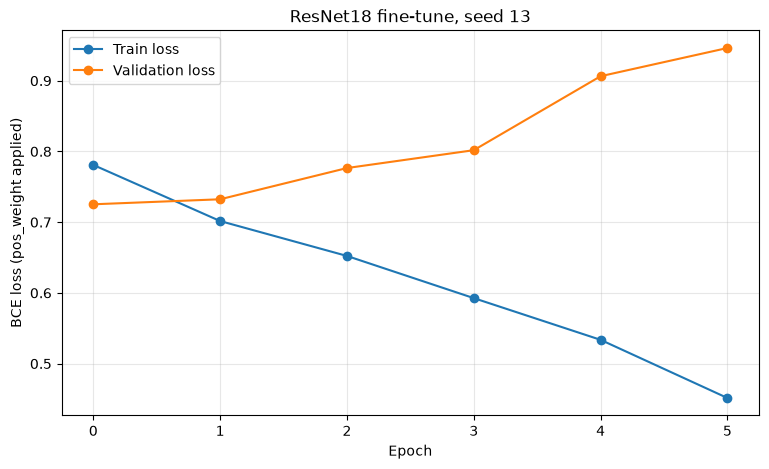

In [86]:
# train vs val loss for the fine tuned resnet18 (seed 13)
# val loss goes up after epoch 1-2 = overfitting, that's why early stopping

plt.figure(figsize=(9, 5))
plt.plot(curve_history["train_loss"], marker="o", label="Train loss")
plt.plot(curve_history["val_loss"], marker="o", label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("BCE loss (pos_weight applied)")
plt.title("ResNet18 fine-tune, seed 13"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 18. Picking thresholds on validation

In [61]:
# pick thresholds on val (average of the 3 seeds)
# best f1, screening (sens >= 0.90) and high spec (spec >= 0.95)

validation_targets = val_targets

validation_ensemble_probabilities = np.mean(
    np.vstack(final_seed_probabilities),
    axis=0,
)

threshold_grid = np.linspace(
    0.05,
    0.95,
    181,
)

threshold_rows = []

for threshold in threshold_grid:
    metrics = binary_metrics(
        validation_targets,
        validation_ensemble_probabilities,
        threshold=threshold,
    )

    metrics["threshold"] = threshold

    threshold_rows.append(metrics)

threshold_results = pd.DataFrame(
    threshold_rows
)

operating_threshold = threshold_results.loc[
    threshold_results["f1_score"].idxmax(),
    "threshold",
]

screening_threshold = threshold_results.loc[
    threshold_results[
        threshold_results["sensitivity"] >= 0.90
    ]["specificity"].idxmax(),
    "threshold",
]

high_specificity_threshold = threshold_results.loc[
    threshold_results[
        threshold_results["specificity"] >= 0.95
    ]["sensitivity"].idxmax(),
    "threshold",
]

print("F1-selected threshold:", operating_threshold)
print("Screening threshold:", screening_threshold)
print("High-specificity threshold:", high_specificity_threshold)

display(
    threshold_results.sort_values(
        "f1_score",
        ascending=False,
    ).head(10)
)

F1-selected threshold: 0.5399999999999999
Screening threshold: 0.22499999999999998
High-specificity threshold: 0.735


,accuracy,sensitivity,specificity,precision,f1_score,threshold
98,0.830289,0.703583,0.868918,0.620690,0.659542,0.540
94,0.826738,0.713355,0.861304,0.610595,0.657987,0.520
97,0.828513,0.704669,0.866269,0.616334,0.657548,0.535
95,0.826991,0.710098,0.862628,0.611787,0.657286,0.525
96,0.827752,0.706840,0.864614,0.614151,0.657244,0.530
91,0.823440,0.723127,0.854022,0.601626,0.656805,0.505
99,0.829782,0.697068,0.870242,0.620890,0.656777,0.545
86,0.818366,0.743757,0.841112,0.587983,0.656759,0.480
92,0.824455,0.718784,0.856670,0.604566,0.656746,0.510
93,0.824708,0.716612,0.857663,0.605505,0.656390,0.515


## 19. Test set results

In [50]:
# extra: averaging the 3 seeds (ensemble) is more than the brief asks (it only asks for mean/std over seeds), I did it because it gives a more stable final score than picking one seed
# test set: load the 3 models and average their predictions

cnn_test_dataset = ChestXrayDataset(test_df, augmentation=None)
cnn_test_loader = DataLoader(
    cnn_test_dataset, batch_size=CNN_BATCH_SIZE, shuffle=False, num_workers=0
)

test_probabilities_per_seed = []

for seed in FINAL_SEEDS:
    checkpoint = torch.load(
        CKPT_DIR / f"final_seed_{seed}.pt", map_location=device, weights_only=False
    )

    model, _, _, _ = build_final_model(FINAL_MODEL_NAME)
    model.load_state_dict(checkpoint["state"])

    probabilities, test_targets = predict_cnn_probabilities(model, cnn_test_loader)
    test_probabilities_per_seed.append(probabilities)

    print(f"seed {seed}: test PR-AUC "
          f"{average_precision_score(test_targets, probabilities):.4f}")

    del model

final_test_probabilities = np.mean(np.vstack(test_probabilities_per_seed), axis=0)

test_predictions = test_df.reset_index(drop=True).copy()
test_predictions["probability"] = final_test_probabilities

assert np.array_equal(test_predictions["Target"].to_numpy(), test_targets)

print(f"\nensemble test PR-AUC "
      f"{average_precision_score(test_targets, final_test_probabilities):.4f}")
display(test_predictions[["patientId", "ViewPosition", "Target", "probability"]].head())

seed 13: test PR-AUC 0.6950
seed 31: test PR-AUC 0.6811
seed 42: test PR-AUC 0.6763

ensemble test PR-AUC 0.6990


,patientId,ViewPosition,Target,probability
0,1.2.276.0.7230010.3.1.4.8323329.10002.15178743...,PA,0,0.156475
1,1.2.276.0.7230010.3.1.4.8323329.10012.15178743...,AP,0,0.123579
2,1.2.276.0.7230010.3.1.4.8323329.10013.15178743...,PA,0,0.014407
3,1.2.276.0.7230010.3.1.4.8323329.10022.15178743...,PA,0,0.189770
4,1.2.276.0.7230010.3.1.4.8323329.10024.15178743...,PA,0,0.028443


In [62]:
# confusion matrices on test for the 3 thresholds

for name, thr in [("operating", operating_threshold),
                  ("screening", screening_threshold),
                  ("high_spec", high_specificity_threshold)]:
    preds = (final_test_probabilities >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_targets, preds, labels=[0,1]).ravel()
    print(f"\n{name} (thr={thr:.3f})  TN={tn} FP={fp} FN={fn} TP={tp}")
    print(f"  sens={tp/(tp+fn):.3f}  spec={tn/(tn+fp):.3f}  prec={tp/(tp+fp):.3f}")


operating (thr=0.540)  TN=2622 FP=414 FN=281 TP=603
  sens=0.682  spec=0.864  prec=0.593

screening (thr=0.225)  TN=1934 FP=1102 FN=88 TP=796
  sens=0.900  spec=0.637  prec=0.419

high_spec (thr=0.735)  TN=2883 FP=153 FN=466 TP=418
  sens=0.473  spec=0.950  prec=0.732


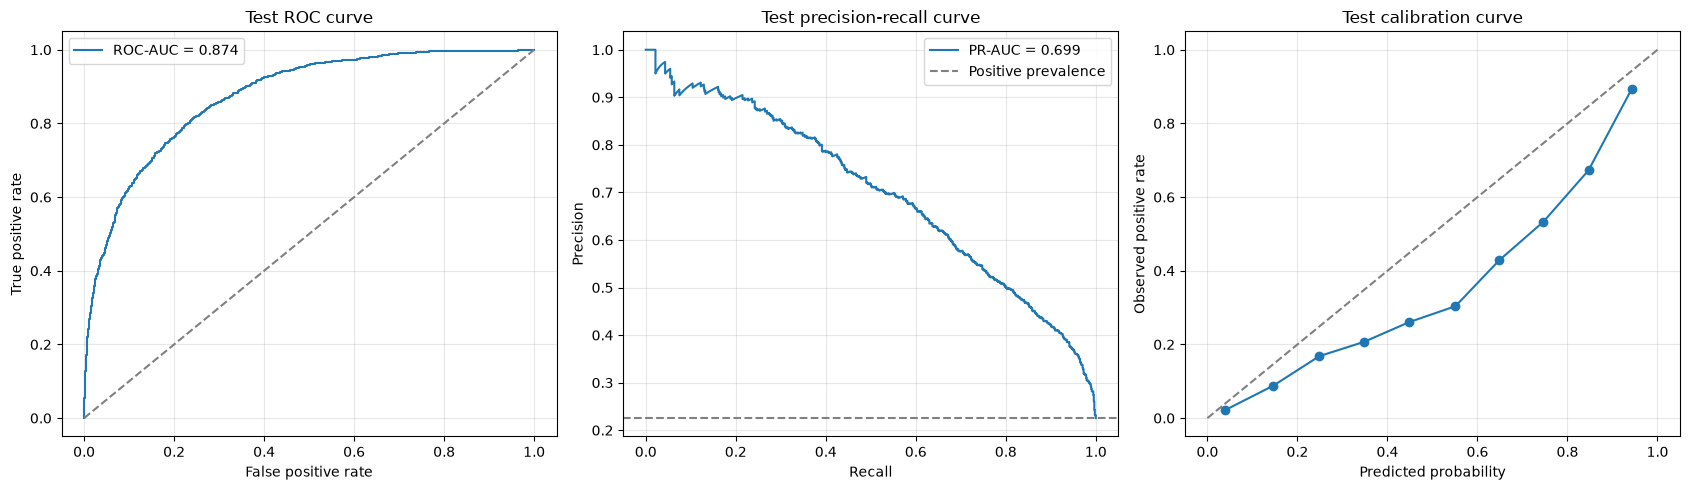

In [24]:
# roc, pr and calibration curves on test

from sklearn.calibration import calibration_curve

from sklearn.metrics import (
    auc,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

fpr, tpr, _ = roc_curve(
    test_targets,
    final_test_probabilities,
)

precision, recall, _ = precision_recall_curve(
    test_targets,
    final_test_probabilities,
)

observed_rate, predicted_probability = calibration_curve(
    test_targets,
    final_test_probabilities,
    n_bins=10,
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(17, 5),
)

axes[0].plot(
    fpr,
    tpr,
    label=(
        f"ROC-AUC = "
        f"{roc_auc_score(test_targets, final_test_probabilities):.3f}"
    ),
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
)

axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("Test ROC curve")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    recall,
    precision,
    label=(
        f"PR-AUC = "
        f"{average_precision_score(test_targets, final_test_probabilities):.3f}"
    ),
)

axes[1].axhline(
    test_targets.mean(),
    linestyle="--",
    color="gray",
    label="Positive prevalence",
)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Test precision-recall curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
)

axes[2].plot(
    predicted_probability,
    observed_rate,
    marker="o",
)

axes[2].set_xlabel("Predicted probability")
axes[2].set_ylabel("Observed positive rate")
axes[2].set_title("Test calibration curve")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
# comparison table on test (trivial vs simple vs cnn)

from sklearn.metrics import roc_auc_score, average_precision_score

cnn_row = binary_metrics(
    test_targets, final_test_probabilities, threshold=operating_threshold
)
cnn_row["roc_auc"] = roc_auc_score(test_targets, final_test_probabilities)
cnn_row["pr_auc"] = average_precision_score(test_targets, final_test_probabilities)

comparison = pd.DataFrame(
    [trivial_test_metrics, simple_test_metrics, cnn_row],
    index=["Trivial (majority class)", "Simple logistic (4 features)", "ResNet18 CNN"],
)

display(comparison.round(4))

,accuracy,sensitivity,specificity,precision,f1_score,roc_auc,pr_auc
Trivial (majority class),0.7745,0.0000,1.0000,0.0000,0.0000,0.5000,0.2255
Simple logistic (4 features),0.6620,0.6233,0.6733,0.3571,0.4541,0.6733,0.3202
ResNet18 CNN,0.8227,0.6821,0.8636,0.5929,0.6344,0.8736,0.6990


## 20. Subgroups (view and sex)

In [78]:
# subgroups: AP vs PA and sex
# AP has way more positives (39% vs 9%)

for column in ["ViewPosition", "PatientSex"]:
    rows = []

    for group, subset in test_predictions.groupby(column):
        predicted = (subset["probability"] >= operating_threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            subset["Target"], predicted, labels=[0, 1]
        ).ravel()

        rows.append({
            column: group,
            "n": len(subset),
            "prevalence": subset["Target"].mean(),
            "sensitivity": tp / (tp + fn) if (tp + fn) else np.nan,
            "specificity": tn / (tn + fp) if (tn + fp) else np.nan,
            "pr_auc": average_precision_score(subset["Target"], subset["probability"]),
        })

    display(pd.DataFrame(rows).round(4))

,ViewPosition,n,prevalence,sensitivity,specificity,pr_auc
0,AP,1771,0.3885,0.7762,0.7285,0.7746
1,PA,2149,0.0912,0.3520,0.9386,0.3579


,PatientSex,n,prevalence,sensitivity,specificity,pr_auc
0,F,1647,0.2016,0.6536,0.8867,0.6901
1,M,2273,0.2429,0.6993,0.8460,0.7058


## 21. Grad-CAM

In [80]:
# pick one TP, TN, FP, FN (most confident ones) with the seed 13 model

ckpt = torch.load(CKPT_DIR / "final_seed_13.pt", map_location=device, weights_only=False)
model, _, _, _ = build_final_model(FINAL_MODEL_NAME)
model.load_state_dict(ckpt["state"])
model.eval()

tp_ = test_predictions[(test_predictions.Target==1)&(test_predictions.probability>=operating_threshold)].nlargest(1,"probability")
tn_ = test_predictions[(test_predictions.Target==0)&(test_predictions.probability< operating_threshold)].nsmallest(1,"probability")
fp_ = test_predictions[(test_predictions.Target==0)&(test_predictions.probability>=operating_threshold)].nlargest(1,"probability")
fn_ = test_predictions[(test_predictions.Target==1)&(test_predictions.probability< operating_threshold)].nsmallest(1,"probability")

cases = pd.concat([tp_, tn_, fp_, fn_])
cases["kind"] = ["TP","TN","FP","FN"]
display(cases[["kind","patientId","ViewPosition","Target","probability"]])

,kind,patientId,ViewPosition,Target,probability
1005,TP,1.2.276.0.7230010.3.1.4.8323329.17358.15178744...,AP,1,0.995553
2241,TN,1.2.276.0.7230010.3.1.4.8323329.26070.15178744...,PA,0,0.000592
3048,FP,1.2.276.0.7230010.3.1.4.8323329.3368.151787430...,AP,0,0.980340
1150,FN,1.2.276.0.7230010.3.1.4.8323329.1837.151787429...,PA,1,0.006542


In [81]:
# grad-cam on the last block of layer4

target_layer = model.layer4[-1]
activations, gradients = {}, {}

target_layer.register_forward_hook(
    lambda m, i, o: activations.update(v=o.detach())
)
target_layer.register_full_backward_hook(
    lambda m, gi, go: gradients.update(v=go[0].detach())
)

def grad_cam(path):
    x = preprocess_for_cnn(path, augmentation=None).unsqueeze(0).to(device)
    model.zero_grad()
    logit = model(x)
    logit.backward()
    w = gradients["v"].mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((w * activations["v"]).sum(1))[0].cpu().numpy()
    cam = cam - cam.min()
    return cam / (cam.max() + 1e-9), torch.sigmoid(logit).item()

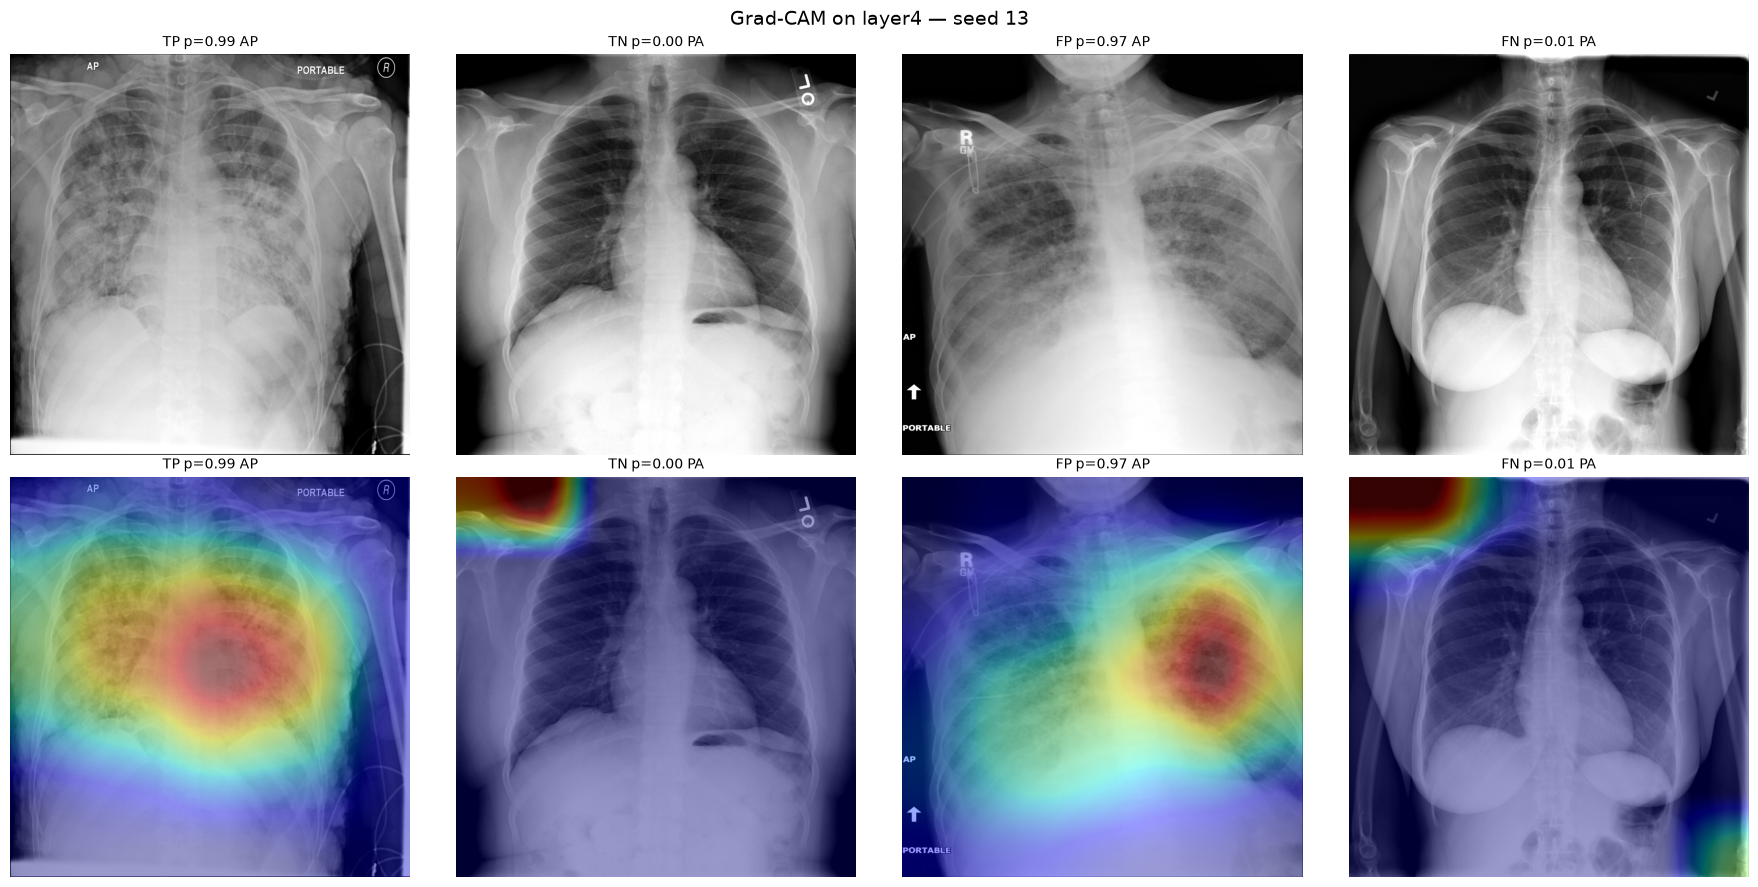

In [84]:
# grad-cam plots, top = x-ray, bottom = overlay

from PIL import Image
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for i, row in enumerate(cases.itertuples()):
    img = pydicom.dcmread(row.dicom_path).pixel_array
    cam, p = grad_cam(row.dicom_path)
    cam_big = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize(img.shape[::-1]))
    lo, hi = np.percentile(img, [1, 99])
    for r, overlay in enumerate([False, True]):
        ax = axes[r, i]
        ax.imshow(img, cmap="gray", vmin=lo, vmax=hi)
        if overlay:
            ax.imshow(cam_big, cmap="jet", alpha=0.4)
        ax.set_title(f"{row.kind} p={p:.2f} {row.ViewPosition}", fontsize=10)
        ax.axis("off")
plt.suptitle("Grad-CAM on layer4 — seed 13", fontsize=14)
plt.tight_layout(); plt.show()

## 22. Bonus questions

### Bonus 1: prevalence shift and threshold transfer

In [ ]:
# bonus 1: 10% and 40% prevalence versions of the test set, subsampling one class only
# no retraining, and the screening threshold is the one frozen on validation

positives = test_predictions[test_predictions["Target"] == 1]
negatives = test_predictions[test_predictions["Target"] == 0]

n_pos_10 = round(len(negatives) * 0.10 / 0.90)  # keep all negatives, drop positives
n_neg_40 = round(len(positives) * 0.60 / 0.40)  # keep all positives, drop negatives

shift_sets = {
    "original test": test_predictions,
    "10% prevalence": pd.concat([positives.sample(n_pos_10, random_state=31), negatives]),
    "40% prevalence": pd.concat([positives, negatives.sample(n_neg_40, random_state=31)]),
}

rows = []

for name, subset in shift_sets.items():
    metrics = binary_metrics(
        subset["Target"],
        subset["probability"].to_numpy(),
        threshold=screening_threshold,
    )

    rows.append({
        "set": name,
        "n": len(subset),
        "positives": int(subset["Target"].sum()),
        "prevalence": subset["Target"].mean(),
        "sensitivity": metrics["sensitivity"],
        "specificity": metrics["specificity"],
        "precision_ppv": metrics["precision"],
        "f1_score": metrics["f1_score"],
        "roc_auc": roc_auc_score(subset["Target"], subset["probability"]),
    })

print(f"screening threshold (frozen on validation): {screening_threshold:.3f}")
display(pd.DataFrame(rows).set_index("set").round(4))


### Bonus 2: border masking with a lung-field control

In [ ]:
# bonus 2: mask the outer 8% border, and as a control the same area inside the two lung fields
# masks are put on the 0-1 image before imagenet normalisation, so masked pixels are black like the padding

BORDER = round(IMAGE_SIZE * 0.08)
border_area = IMAGE_SIZE ** 2 - (IMAGE_SIZE - 2 * BORDER) ** 2

# two boxes of the same size, one per lung, away from the midline and the edges
LUNG_TOP, LUNG_HEIGHT = 40, 120
LUNG_WIDTH = round(border_area / 2 / LUNG_HEIGHT)
LEFT_X = 32
RIGHT_X = IMAGE_SIZE - 32 - LUNG_WIDTH


def border_mask(image):
    image = image.clone()
    image[..., :BORDER, :] = 0
    image[..., -BORDER:, :] = 0
    image[..., :, :BORDER] = 0
    image[..., :, -BORDER:] = 0
    return image


def lung_mask(image):
    image = image.clone()
    rows = slice(LUNG_TOP, LUNG_TOP + LUNG_HEIGHT)
    image[..., rows, LEFT_X:LEFT_X + LUNG_WIDTH] = 0
    image[..., rows, RIGHT_X:RIGHT_X + LUNG_WIDTH] = 0
    return image


print("border width:", BORDER, "px | border area:", border_area,
      "| lung control area:", 2 * LUNG_HEIGHT * LUNG_WIDTH)

example_images = [dicom_to_image_tensor(p) for p in test_predictions["dicom_path"].iloc[:3]]

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for r, image in enumerate(example_images):
    for ax, (title, shown) in zip(
        axes[r],
        [("original", image), ("border mask", border_mask(image)), ("lung control", lung_mask(image))],
    ):
        ax.imshow(shown[0].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
# run the seed 13 model on every test image: unmasked, border masked and lung masked
# each dicom is read once and the 3 versions go through the model together

p_original, p_border, p_lung = [], [], []
model.eval()

with torch.no_grad():
    for start in tqdm(range(0, len(test_predictions), CNN_BATCH_SIZE), desc="masking test"):
        batch_paths = test_predictions["dicom_path"].iloc[start:start + CNN_BATCH_SIZE]
        base = torch.stack([dicom_to_image_tensor(p) for p in batch_paths])

        for store, mask_fn in [(p_original, None), (p_border, border_mask), (p_lung, lung_mask)]:
            images = base if mask_fn is None else mask_fn(base)
            images = normalize_for_imagenet(images).to(device)
            store.append(torch.sigmoid(model(images)).squeeze(1).cpu().numpy())

mask_results = test_predictions[["patientId", "dicom_path", "ViewPosition", "Target"]].copy()
mask_results["p_original"] = np.concatenate(p_original)
mask_results["delta_border"] = np.concatenate(p_border) - mask_results["p_original"]
mask_results["delta_lung"] = np.concatenate(p_lung) - mask_results["p_original"]

summary_rows = []

for name, column in [("border", "delta_border"), ("lung control", "delta_lung")]:
    delta = mask_results[column]
    masked_p = mask_results["p_original"] + delta

    summary_rows.append({
        "mask": name,
        "mean_delta_p": delta.mean(),
        "median_delta_p": delta.median(),
        "mean_abs_delta_p": delta.abs().mean(),
        "p5": delta.quantile(0.05),
        "p95": delta.quantile(0.95),
        "share_abs_delta_over_0.1": (delta.abs() > 0.1).mean(),
        "pr_auc": average_precision_score(mask_results["Target"], masked_p),
    })

print("unmasked PR-AUC (seed 13):",
      round(average_precision_score(mask_results["Target"], mask_results["p_original"]), 4))
print("images where |delta| is bigger for border than lung control:",
      round((mask_results["delta_border"].abs() > mask_results["delta_lung"].abs()).mean(), 4))
display(pd.DataFrame(summary_rows).set_index("mask").round(4))

bins = np.linspace(-1, 1, 81)
plt.figure(figsize=(9, 4.5))
plt.hist(mask_results["delta_border"], bins=bins, alpha=0.6, label="border (outer 8%)")
plt.hist(mask_results["delta_lung"], bins=bins, alpha=0.6, label="lung control (same area)")
plt.yscale("log")
plt.xlabel("change in predicted probability (masked - original)")
plt.ylabel("number of test images (log)")
plt.title("Distribution of delta p on the test set, seed 13 model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [ ]:
# grad-cam before / after the border mask for the 3 images with the biggest |delta p|

def grad_cam_tensor(image):
    x = normalize_for_imagenet(image).unsqueeze(0).to(device)
    model.zero_grad()
    logit = model(x)
    logit.backward()
    w = gradients["v"].mean(dim=(2, 3), keepdim=True)
    cam = torch.relu((w * activations["v"]).sum(1))[0].cpu().numpy()
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-9)
    cam = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((IMAGE_SIZE, IMAGE_SIZE), Image.BILINEAR))
    return cam, torch.sigmoid(logit).item()


top_border = mask_results.reindex(
    mask_results["delta_border"].abs().sort_values(ascending=False).index
).head(3)

fig, axes = plt.subplots(3, 2, figsize=(8, 12))

for r, row in enumerate(top_border.itertuples()):
    image = dicom_to_image_tensor(row.dicom_path)

    for c, (title, shown) in enumerate([("original", image), ("border masked", border_mask(image))]):
        cam, p = grad_cam_tensor(shown)
        ax = axes[r, c]
        ax.imshow(shown[0].numpy(), cmap="gray", vmin=0, vmax=1)
        ax.imshow(cam, cmap="jet", alpha=0.4)
        ax.set_title(f"{title} | Target={row.Target} {row.ViewPosition} | p={p:.2f}", fontsize=9)
        ax.axis("off")

plt.suptitle("Grad-CAM before and after border masking, largest |delta p|", fontsize=12)
plt.tight_layout()
plt.show()

display(top_border[["patientId", "ViewPosition", "Target", "p_original", "delta_border", "delta_lung"]].round(4))
